In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bodyPerformance.csv to bodyPerformance.csv


In [ ]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12,6)


In [ ]:
# 2. LOAD & CLEAN NAMES
#df = pd.read_csv('bodyPerformance.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_').str.replace('%', 'percent')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Shape: (13393, 12)
Columns: ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_percent', 'diastolic', 'systolic', 'gripForce', 'sit_and_bend_forward_cm', 'sit_ups_counts', 'broad_jump_cm', 'class']


In [ ]:
# 3. REMOVE DUPLICATES
# ============================================================================
df_clean = df.copy()
dupes = df_clean.duplicated().sum()
if dupes > 0:
    df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {dupes}")


Duplicates removed: 1


In [ ]:
# 4. DATA TYPE CONVERSION
# ============================================================================
df_clean['age'] = df_clean['age'].astype(int)
df_clean['sit_ups_counts'] = df_clean['sit_ups_counts'].astype(int)
df_clean['gender'] = df_clean['gender'].replace({'M': 'Male', 'F': 'Female'})


In [ ]:
# 5. MARK UNREALISTIC VALUES AS NaN
# ============================================================================
df_clean.loc[df_clean['body_fat_percent'] > 60, 'body_fat_percent'] = np.nan
df_clean.loc[df_clean['height_cm'] < 130, 'height_cm'] = np.nan
df_clean.loc[df_clean['weight_kg'] < 30, 'weight_kg'] = np.nan
df_clean.loc[df_clean['weight_kg'] > 150, 'weight_kg'] = np.nan
df_clean.loc[df_clean['systolic'] < df_clean['diastolic'], ['systolic', 'diastolic']] = np.nan
df_clean.loc[df_clean['diastolic'] == 0, 'diastolic'] = np.nan
df_clean.loc[df_clean['systolic'] == 0, 'systolic'] = np.nan
df_clean.loc[df_clean['gripForce'] == 0, 'gripForce'] = np.nan
df_clean.loc[df_clean['broad_jump_cm'] == 0, 'broad_jump_cm'] = np.nan

In [ ]:
# 6. DELETE ROWS WITH ANY NaN (NO IMPUTATION)
# ============================================================================
rows_before = len(df_clean)
df_clean = df_clean.dropna()
rows_removed = rows_before - len(df_clean)
print(f"Rows with NaN removed: {rows_removed} ({rows_removed/rows_before*100:.2f}%)")
print(f"Final shape: {df_clean.shape}")


Rows with NaN removed: 21 (0.16%)
Final shape: (13371, 12)


In [ ]:
df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[0,20,30,40,50,60,100],
                                labels=['<20','20-30','30-40','40-50','50-60','60+'])

# ============================================================================


UNIVARIATE ANALYSIS
                age     height_cm     weight_kg  body_fat_percent  \
count  13371.000000  13371.000000  13371.000000      13371.000000   
mean      36.768230    168.568836     67.454689         23.228250   
std       13.621189      8.417261     11.938959          7.234371   
min       21.000000    139.500000     31.900000          3.000000   
25%       25.000000    162.400000     58.200000         18.000000   
50%       32.000000    169.200000     67.440000         22.800000   
75%       48.000000    174.800000     75.300000         28.000000   
max       64.000000    193.800000    138.100000         54.900000   

          diastolic      systolic     gripForce  sit_and_bend_forward_cm  \
count  13371.000000  13371.000000  13371.000000             13371.000000   
mean      78.802685    130.269165     36.981760                15.208865   
std       10.695043     14.612206     10.603831                 8.457920   
min        6.000000     77.000000      1.600000      

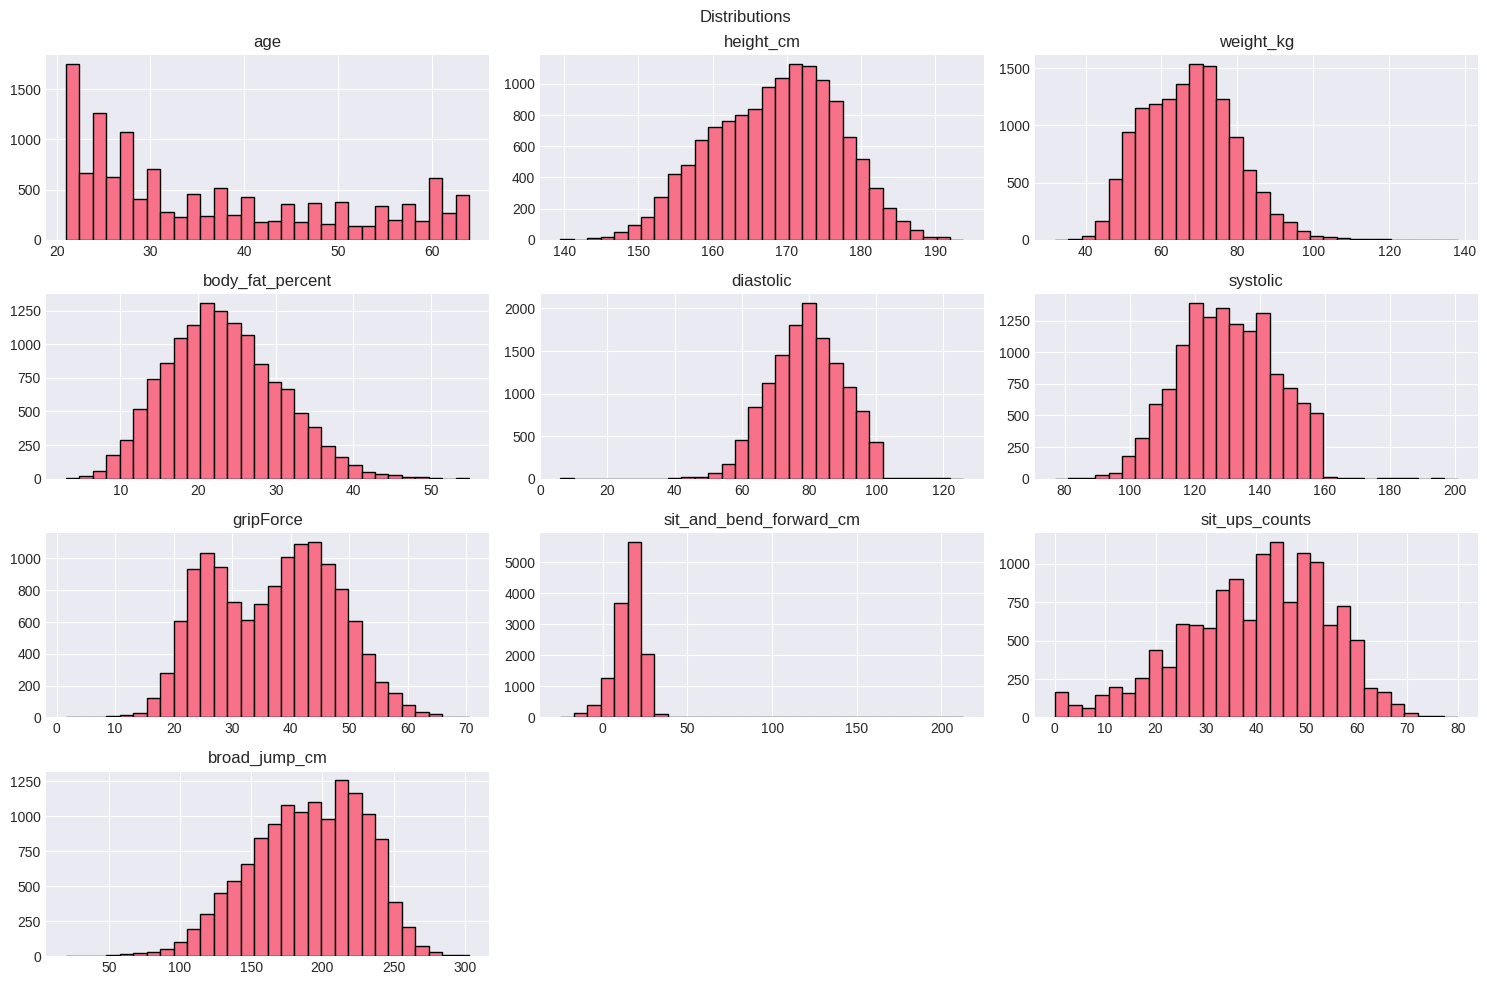

In [ ]:
# 8. UNIVARIATE ANALYSIS
# ============================================================================
num_cols = ['age','height_cm','weight_kg','body_fat_percent','diastolic',
            'systolic','gripForce','sit_and_bend_forward_cm','sit_ups_counts','broad_jump_cm']
num_cols = [c for c in num_cols if c in df_clean.columns]

print("\n" + "="*50)
print("UNIVARIATE ANALYSIS")
print("="*50)
print(df_clean[num_cols].describe())

# Histograms
df_clean[num_cols].hist(bins=30, figsize=(15,10), edgecolor='black')
plt.suptitle('Distributions')
plt.tight_layout()
plt.show()


CORRELATION


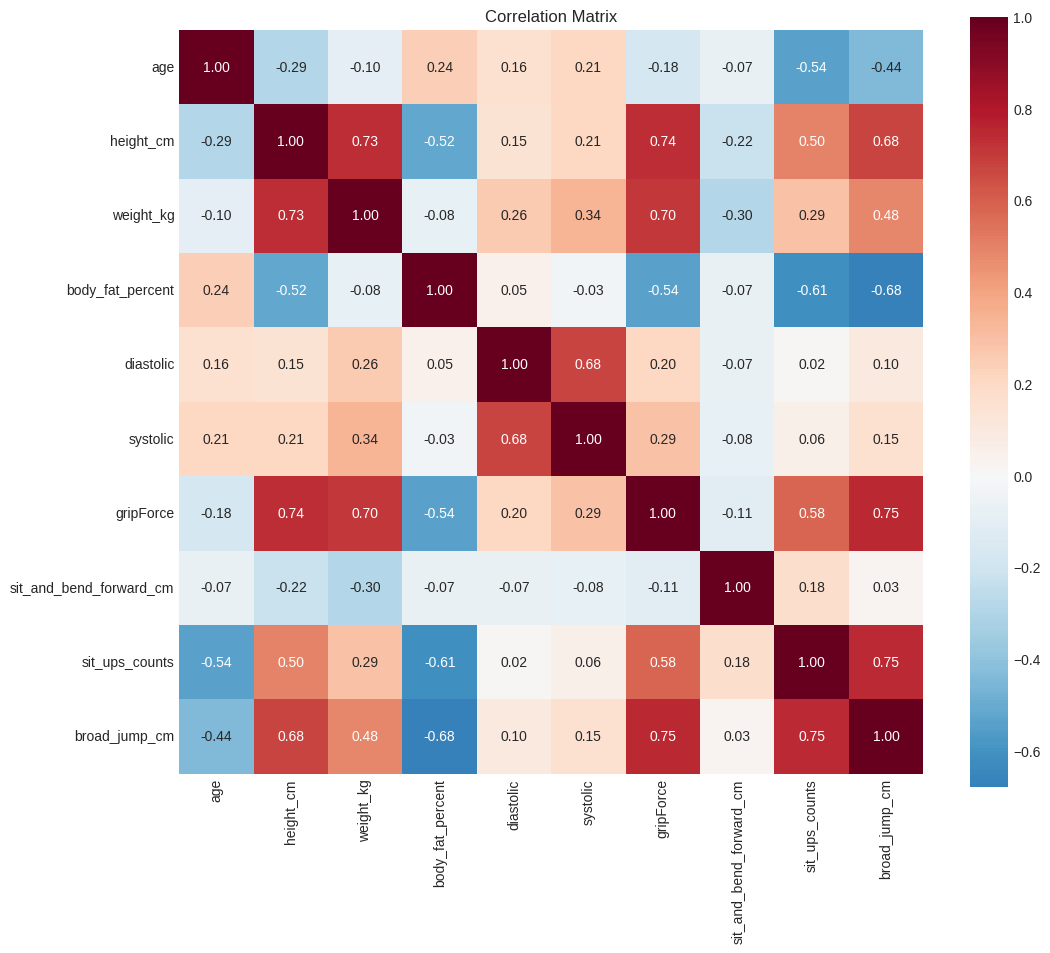

Top 5 positive: [('gripForce', 'broad_jump_cm', np.float64(0.7520923925941577)), ('sit_ups_counts', 'broad_jump_cm', np.float64(0.7500925154081562)), ('height_cm', 'gripForce', np.float64(0.735773239094416)), ('height_cm', 'weight_kg', np.float64(0.7347278780366129)), ('weight_kg', 'gripForce', np.float64(0.7009696760352555))]
Top 5 negative: [('systolic', 'sit_ups_counts', np.float64(0.05769542647457346)), ('body_fat_percent', 'diastolic', np.float64(0.05014119815032365)), ('body_fat_percent', 'systolic', np.float64(-0.030051540317545703)), ('sit_and_bend_forward_cm', 'broad_jump_cm', np.float64(0.025953549225761215)), ('diastolic', 'sit_ups_counts', np.float64(0.015482121813048819))]


In [ ]:
# 9. CORRELATION
# ============================================================================
print("\n" + "="*50)
print("CORRELATION")
print("="*50)
corr = df_clean[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix')
plt.show()

# Top correlations
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("Top 5 positive:", corr_pairs[:5])
print("Top 5 negative:", corr_pairs[-5:])



BOXPLOTS


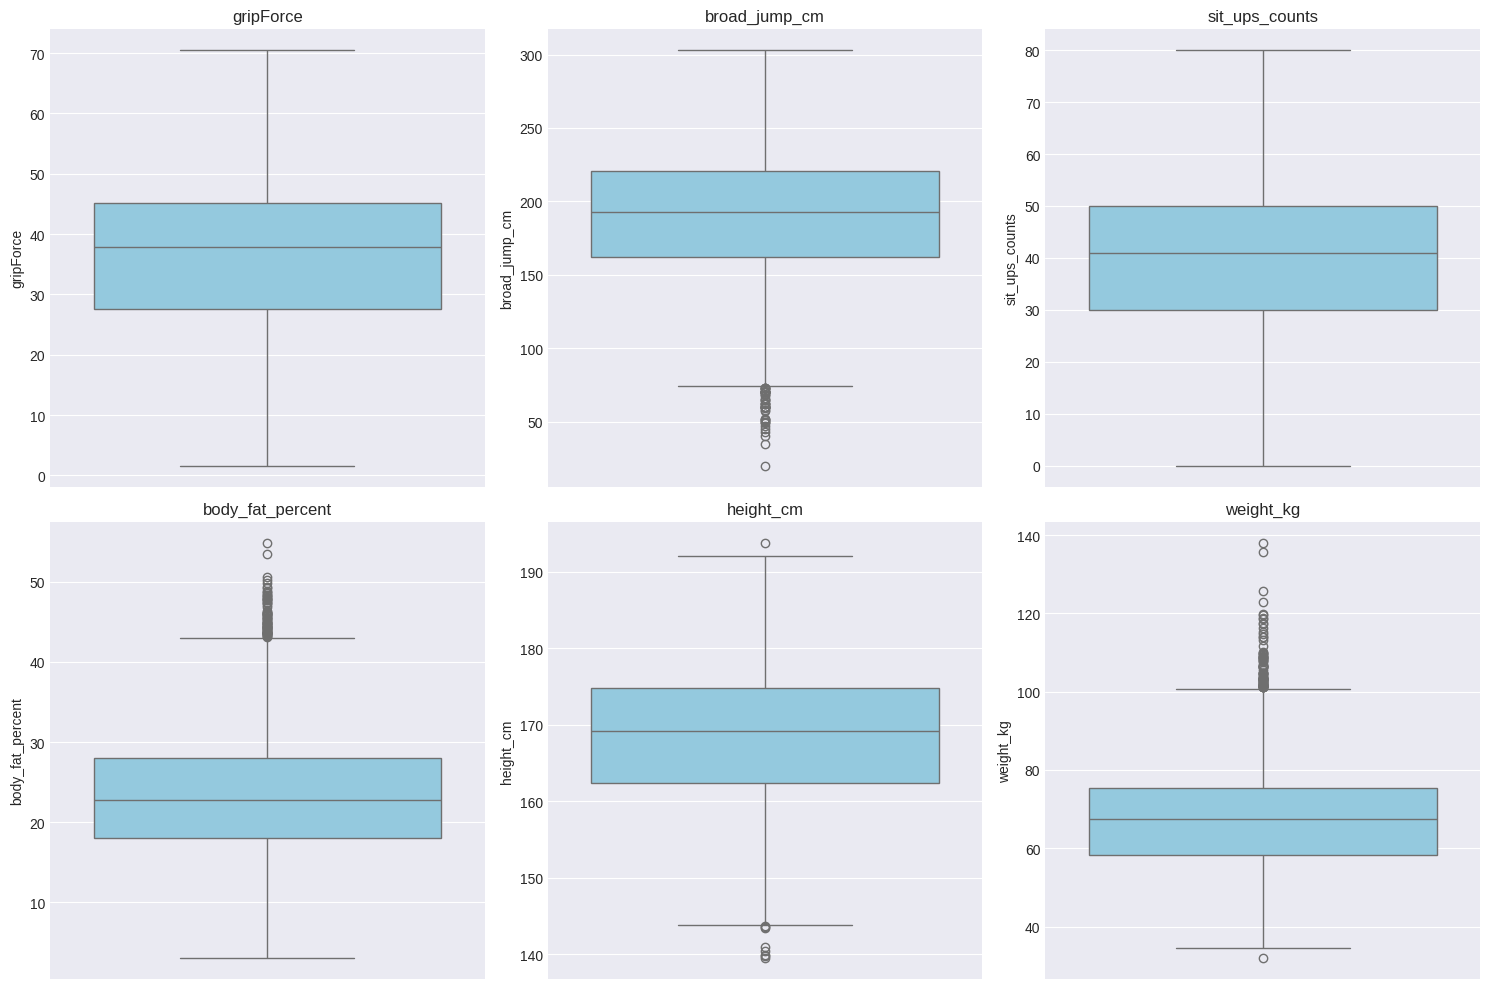

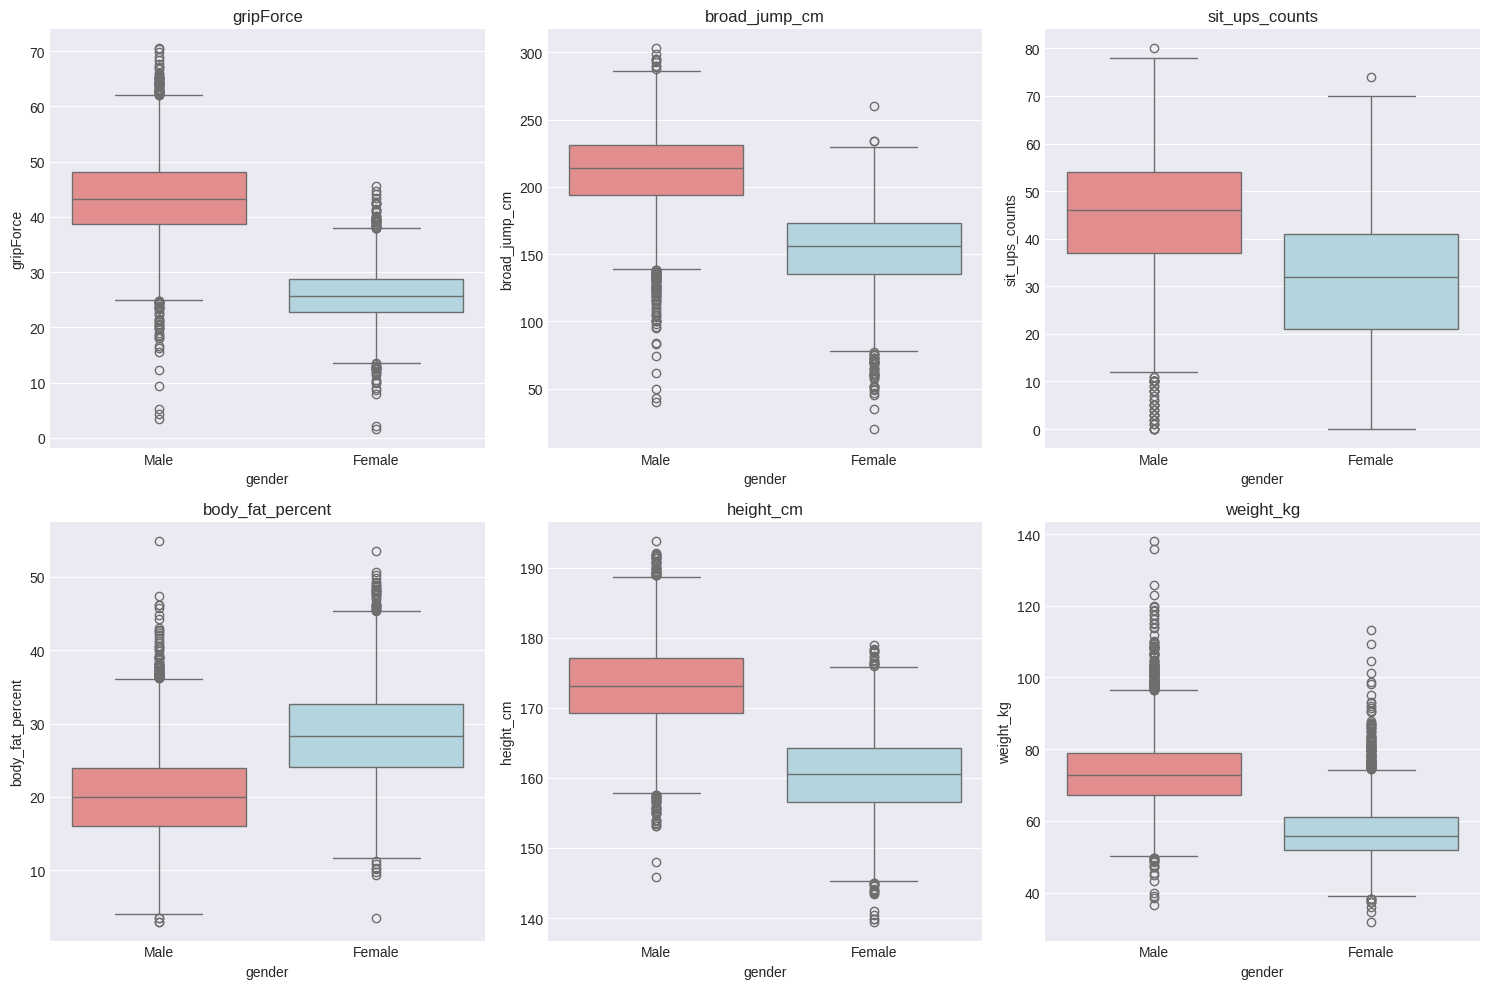

In [ ]:
# 10. BOXPLOTS
# ============================================================================
print("\n" + "="*50)
print("BOXPLOTS")
print("="*50)

fig, axes = plt.subplots(2,3, figsize=(15,10))
plot_cols = ['gripForce','broad_jump_cm','sit_ups_counts','body_fat_percent','height_cm','weight_kg']
plot_cols = [c for c in plot_cols if c in df_clean.columns]

for i, col in enumerate(plot_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i//3, i%3], color='skyblue')
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

# Gender boxplots
fig, axes = plt.subplots(2,3, figsize=(15,10))
for i, col in enumerate(plot_cols):
    sns.boxplot(x='gender', y=col, data=df_clean, ax=axes[i//3, i%3], palette=['lightcoral','lightblue'])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()



SCATTER PLOTS


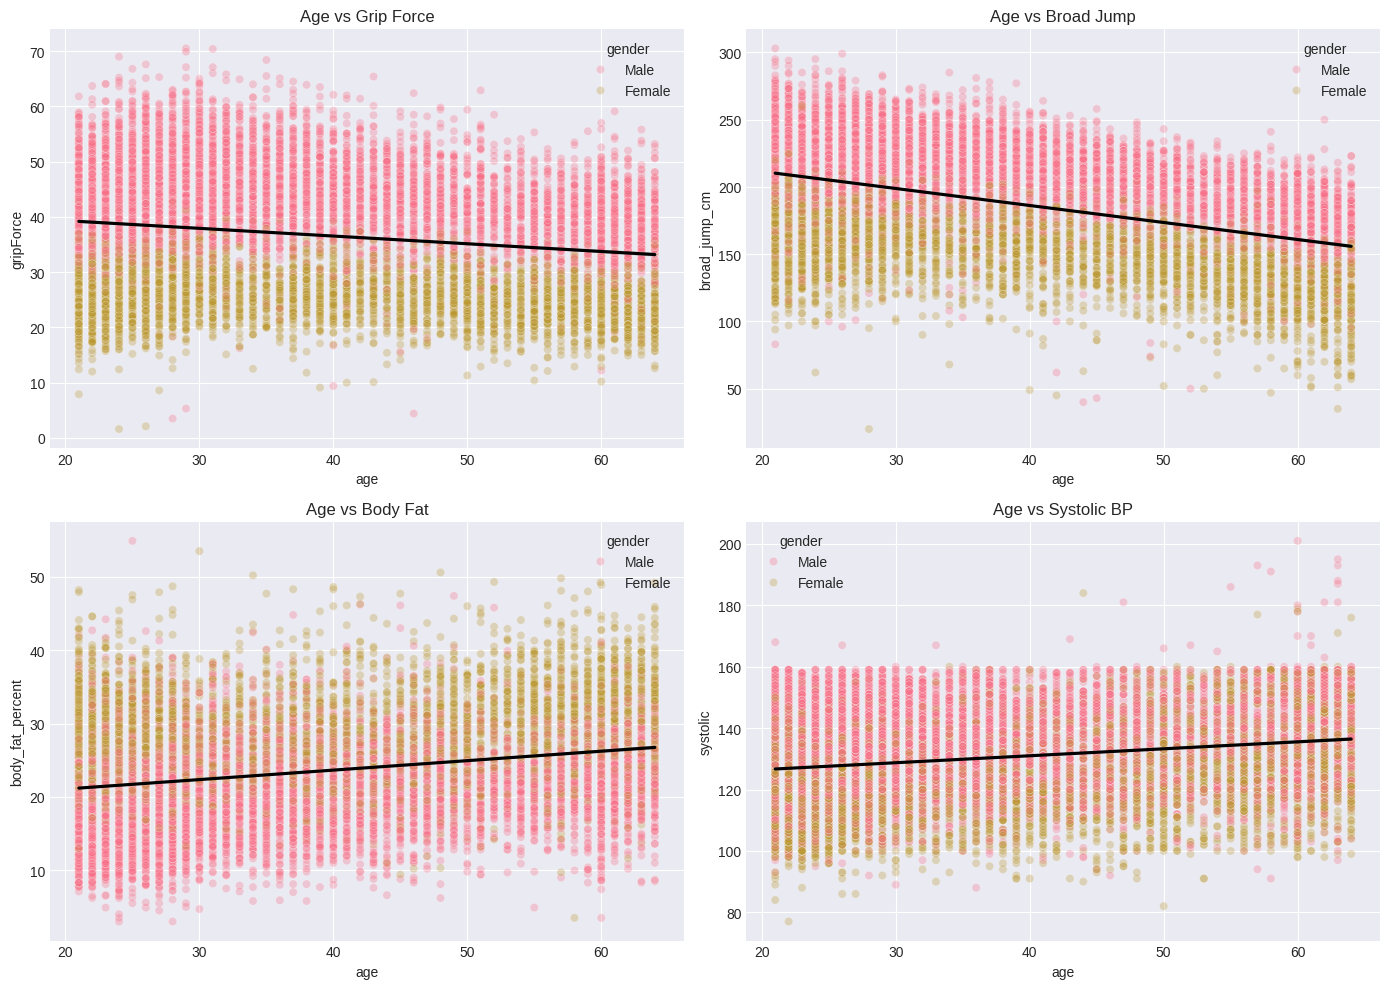

In [ ]:
# 11. SCATTER PLOTS (Age vs Performance)
# ============================================================================
print("\n" + "="*50)
print("SCATTER PLOTS")
print("="*50)

fig, axes = plt.subplots(2,2, figsize=(14,10))
scatters = [('gripForce','Grip Force'), ('broad_jump_cm','Broad Jump'),
            ('body_fat_percent','Body Fat'), ('systolic','Systolic BP')]

for i, (col, title) in enumerate(scatters):
    if col in df_clean.columns:
        sns.scatterplot(x='age', y=col, hue='gender', data=df_clean, alpha=0.3, ax=axes[i//2, i%2])
        sns.regplot(x='age', y=col, data=df_clean, scatter=False, ax=axes[i//2, i%2], color='black')
        axes[i//2, i%2].set_title(f'Age vs {title}')
plt.tight_layout()
plt.show()

In [ ]:
# 13. FINAL SUMMARY
# ============================================================================
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Final shape: {df_clean.shape}")
print(f"Gender: {df_clean['gender'].value_counts().to_dict()}")
print(f"Class: {df_clean['class'].value_counts().to_dict()}")
print(f"Age groups: {sorted(df_clean['age_group'].unique())}")


FINAL SUMMARY
Final shape: (13371, 13)
Gender: {'Male': 8458, 'Female': 4913}
Class: {'A': 3345, 'B': 3344, 'C': 3343, 'D': 3339}
Age groups: ['20-30', '30-40', '40-50', '50-60', '60+']


##**KNN**









# Part 2 – Machine Learning Model Training
## K-Nearest Neighbors (KNN) Classifier

**Dataset:** Body Performance Dataset  
**Task:** Classification – Predict the performance `class` variable  
**Model:** K-Nearest Neighbors (KNN) with hyperparameter tuning on `k`

---
This notebook continues directly after the EDA notebook.  
The cleaned dataframe `df_clean` is assumed to be available (re-loaded below for reproducibility).

In [ ]:
# ============================================================
# CELL 1 – IMPORTS
# ============================================================
# Scikit-learn – preprocessing
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection  import train_test_split, KFold, cross_val_score

# Scikit-learn – model
from sklearn.neighbors        import KNeighborsClassifier

# Scikit-learn – evaluation
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful.')

All imports successful.


In [ ]:
# CELL 2 – RE-LOAD & REPRODUCE CLEANED DATA (from EDA)
# ============================================================

df = pd.read_csv('bodyPerformance.csv')
df.columns = (df.columns
               .str.strip()
               .str.replace(' ', '_')
               .str.replace('-', '_')
               .str.replace('%', 'percent'))

df_clean = df.copy()

# --- Duplicates ---
df_clean = df_clean.drop_duplicates()

# --- Type fixes ---
df_clean['age']            = df_clean['age'].astype(int)
df_clean['sit_ups_counts'] = df_clean['sit_ups_counts'].astype(int)
df_clean['gender']         = df_clean['gender'].replace({'M': 'Male', 'F': 'Female'})

# --- Mark unrealistic values as NaN ---
df_clean.loc[df_clean['body_fat_percent'] > 60,  'body_fat_percent']  = np.nan
df_clean.loc[df_clean['height_cm']        < 130, 'height_cm']         = np.nan
df_clean.loc[df_clean['weight_kg']        < 30,  'weight_kg']          = np.nan
df_clean.loc[df_clean['weight_kg']        > 150, 'weight_kg']          = np.nan
df_clean.loc[df_clean['systolic'] < df_clean['diastolic'],
             ['systolic', 'diastolic']] = np.nan
df_clean.loc[df_clean['diastolic'] == 0, 'diastolic']   = np.nan
df_clean.loc[df_clean['systolic']  == 0, 'systolic']    = np.nan
df_clean.loc[df_clean['gripForce'] == 0, 'gripForce']   = np.nan
df_clean.loc[df_clean['broad_jump_cm'] == 0, 'broad_jump_cm'] = np.nan

# --- Drop rows with any NaN ---
df_clean = df_clean.dropna()
df_clean = df_clean.reset_index(drop=True)

print(f'Cleaned dataset shape : {df_clean.shape}')
print(f'Class distribution    :\n{df_clean["class"].value_counts()}')

Cleaned dataset shape : (13371, 12)
Class distribution    :
class
A    3345
B    3344
C    3343
D    3339
Name: count, dtype: int64


---
## Cell 3 – Feature Engineering & Encoding

**Decisions taken:**
- `gender` is encoded using `LabelEncoder` (Male=1 / Female=0).
- The target `class` (A/B/C/D) is encoded with `LabelEncoder`.
- The engineered column `age_group` is **dropped** to avoid data leakage and because the raw `age` already carries the same information.
- All numerical features are **standardised** with `StandardScaler` because KNN is distance-based and is highly sensitive to feature scale.

In [ ]:
# CELL 3 – FEATURE ENGINEERING & ENCODING
# ============================================================

df_model = df_clean.copy()

# Drop engineered helper column if present
if 'age_group' in df_model.columns:
    df_model = df_model.drop(columns=['age_group'])

# --- Encode gender ---
le_gender         = LabelEncoder()
df_model['gender'] = le_gender.fit_transform(df_model['gender'])  # Female=0, Male=1
print(f'Gender classes : {le_gender.classes_}')

# --- Encode target ---
le_class          = LabelEncoder()
df_model['class'] = le_class.fit_transform(df_model['class'])     # A=0, B=1, C=2, D=3
print(f'Class labels   : {le_class.classes_}')

# --- Features / Target split ---
feature_cols = [c for c in df_model.columns if c != 'class']
X = df_model[feature_cols]
y = df_model['class']

print(f'\nFeatures used  : {feature_cols}')
print(f'X shape        : {X.shape}')
print(f'y distribution :\n{pd.Series(le_class.inverse_transform(y)).value_counts()}')

Gender classes : ['Female' 'Male']
Class labels   : ['A' 'B' 'C' 'D']

Features used  : ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_percent', 'diastolic', 'systolic', 'gripForce', 'sit_and_bend_forward_cm', 'sit_ups_counts', 'broad_jump_cm']
X shape        : (13371, 11)
y distribution :
A    3345
B    3344
C    3343
D    3339
Name: count, dtype: int64


---
## Cell 4 – Scaling

KNN computes Euclidean distance between samples.  
Without scaling, features with large ranges (e.g. `broad_jump_cm` ~190) would dominate
features with small ranges (e.g. `body_fat_percent` ~23), producing biased distances.

> **Decision:** Apply `StandardScaler` (zero mean, unit variance) on all numeric features.

In [ ]:
# ============================================================
# CELL 4 – STANDARD SCALING
# ============================================================

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('Feature means after scaling (should be ~0):')
print(X_scaled.mean().round(4))
print('\nFeature std after scaling (should be ~1):')
print(X_scaled.std().round(4))

Feature means after scaling (should be ~0):
age                       -0.0
gender                    -0.0
height_cm                  0.0
weight_kg                  0.0
body_fat_percent           0.0
diastolic                  0.0
systolic                  -0.0
gripForce                  0.0
sit_and_bend_forward_cm    0.0
sit_ups_counts             0.0
broad_jump_cm             -0.0
dtype: float64

Feature std after scaling (should be ~1):
age                        1.0
gender                     1.0
height_cm                  1.0
weight_kg                  1.0
body_fat_percent           1.0
diastolic                  1.0
systolic                   1.0
gripForce                  1.0
sit_and_bend_forward_cm    1.0
sit_ups_counts             1.0
broad_jump_cm              1.0
dtype: float64


In [ ]:
# ============================================================
# CELL 5 – EXPERIMENT 1 : 80/20 SPLIT  (k=5 as baseline)
# ============================================================

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

knn_80 = KNeighborsClassifier(n_neighbors=5)
knn_80.fit(X_train_80, y_train_80)
y_pred_80 = knn_80.predict(X_test_80)

acc_80  = accuracy_score(y_test_80, y_pred_80)
prec_80 = precision_score(y_test_80, y_pred_80, average='weighted')
rec_80  = recall_score(y_test_80, y_pred_80, average='weighted')
f1_80   = f1_score(y_test_80, y_pred_80, average='weighted')

print('===== 80/20 SPLIT – KNN (k=5) =====')
print(f'Train size : {len(X_train_80)} | Test size : {len(X_test_80)}')
print(f'Accuracy   : {acc_80:.4f}')
print(f'Precision  : {prec_80:.4f}')
print(f'Recall     : {rec_80:.4f}')
print(f'F1 Score   : {f1_80:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_80, y_pred_80, target_names=le_class.classes_))

===== 80/20 SPLIT – KNN (k=5) =====
Train size : 10696 | Test size : 2675
Accuracy   : 0.5899
Precision  : 0.6150
Recall     : 0.5899
F1 Score   : 0.5899

Classification Report:
              precision    recall  f1-score   support

           A       0.58      0.82      0.68       669
           B       0.42      0.45      0.44       669
           C       0.55      0.44      0.49       669
           D       0.91      0.65      0.75       668

    accuracy                           0.59      2675
   macro avg       0.62      0.59      0.59      2675
weighted avg       0.62      0.59      0.59      2675



In [ ]:
# ============================================================
# CELL 6 – EXPERIMENT 2 : 70/30 SPLIT
# ============================================================

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

knn_70 = KNeighborsClassifier(n_neighbors=5)
knn_70.fit(X_train_70, y_train_70)
y_pred_70 = knn_70.predict(X_test_70)

acc_70  = accuracy_score(y_test_70, y_pred_70)
prec_70 = precision_score(y_test_70, y_pred_70, average='weighted')
rec_70  = recall_score(y_test_70, y_pred_70, average='weighted')
f1_70   = f1_score(y_test_70, y_pred_70, average='weighted')

print('===== 70/30 SPLIT – KNN (k=5) =====')
print(f'Train size : {len(X_train_70)} | Test size : {len(X_test_70)}')
print(f'Accuracy   : {acc_70:.4f}')
print(f'Precision  : {prec_70:.4f}')
print(f'Recall     : {rec_70:.4f}')
print(f'F1 Score   : {f1_70:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_70, y_pred_70, target_names=le_class.classes_))

===== 70/30 SPLIT – KNN (k=5) =====
Train size : 9359 | Test size : 4012
Accuracy   : 0.5917
Precision  : 0.6188
Recall     : 0.5917
F1 Score   : 0.5943

Classification Report:
              precision    recall  f1-score   support

           A       0.59      0.80      0.68      1004
           B       0.42      0.45      0.43      1003
           C       0.55      0.47      0.51      1003
           D       0.92      0.64      0.76      1002

    accuracy                           0.59      4012
   macro avg       0.62      0.59      0.59      4012
weighted avg       0.62      0.59      0.59      4012



In [ ]:
# ============================================================
# CELL 7 – EXPERIMENT 3 : 50/50 SPLIT
# ============================================================

X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(
    X_scaled, y, test_size=0.50, random_state=42, stratify=y
)

knn_50 = KNeighborsClassifier(n_neighbors=5)
knn_50.fit(X_train_50, y_train_50)
y_pred_50 = knn_50.predict(X_test_50)

acc_50  = accuracy_score(y_test_50, y_pred_50)
prec_50 = precision_score(y_test_50, y_pred_50, average='weighted')
rec_50  = recall_score(y_test_50, y_pred_50, average='weighted')
f1_50   = f1_score(y_test_50, y_pred_50, average='weighted')

print('===== 50/50 SPLIT – KNN (k=5) =====')
print(f'Train size : {len(X_train_50)} | Test size : {len(X_test_50)}')
print(f'Accuracy   : {acc_50:.4f}')
print(f'Precision  : {prec_50:.4f}')
print(f'Recall     : {rec_50:.4f}')
print(f'F1 Score   : {f1_50:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_50, y_pred_50, target_names=le_class.classes_))

===== 50/50 SPLIT – KNN (k=5) =====
Train size : 6685 | Test size : 6686
Accuracy   : 0.5842
Precision  : 0.6102
Recall     : 0.5842
F1 Score   : 0.5860

Classification Report:
              precision    recall  f1-score   support

           A       0.59      0.80      0.68      1673
           B       0.42      0.46      0.44      1672
           C       0.54      0.46      0.50      1672
           D       0.90      0.62      0.73      1669

    accuracy                           0.58      6686
   macro avg       0.61      0.58      0.59      6686
weighted avg       0.61      0.58      0.59      6686



===== 10-FOLD CROSS VALIDATION – KNN (k=5) =====
  Fold  1: 0.5747
  Fold  2: 0.6006
  Fold  3: 0.5901
  Fold  4: 0.6200
  Fold  5: 0.6200
  Fold  6: 0.5894
  Fold  7: 0.5841
  Fold  8: 0.5901
  Fold  9: 0.5871
  Fold 10: 0.6006

Mean Accuracy : 0.5957
Std  Accuracy : 0.0141


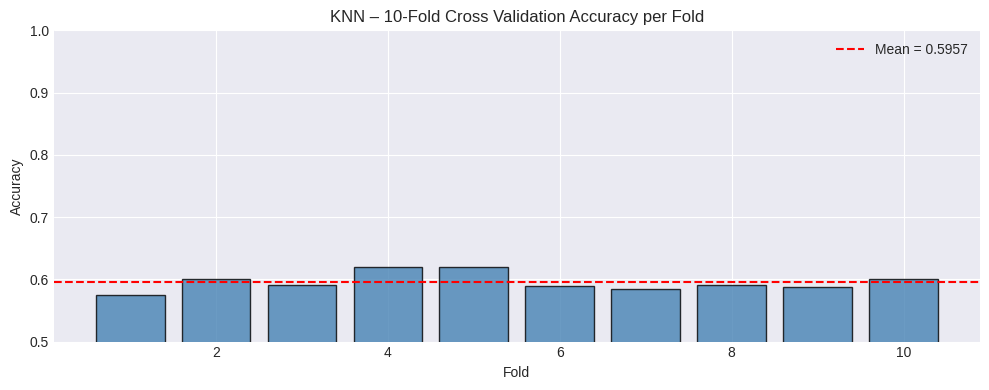

In [ ]:
# ============================================================
# CELL 8 – K-FOLD CROSS VALIDATION  (10 folds)
# ============================================================

kfold     = KFold(n_splits=10, shuffle=True, random_state=42)
knn_cv    = KNeighborsClassifier(n_neighbors=5)

cv_scores = cross_val_score(knn_cv, X_scaled, y, cv=kfold, scoring='accuracy')

print('===== 10-FOLD CROSS VALIDATION – KNN (k=5) =====')
for fold_i, score in enumerate(cv_scores, 1):
    print(f'  Fold {fold_i:2d}: {score:.4f}')

print(f'\nMean Accuracy : {cv_scores.mean():.4f}')
print(f'Std  Accuracy : {cv_scores.std():.4f}')

# Plot fold scores
plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), cv_scores, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('KNN – 10-Fold Cross Validation Accuracy per Fold')
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

---
## Cell 9 – Hyperparameter Tuning: Finding the Best `k`

We sweep `k` from 1 to 30 and record accuracy on the **80/20 test set** for each value.

> **Why tune k?**  
> - Small `k` → low bias, high variance (overfitting).  
> - Large `k` → high bias, low variance (underfitting).  
> - The elbow point in the accuracy curve identifies the optimal `k`.

Best k         : 30
Best Test Acc  : 0.6277


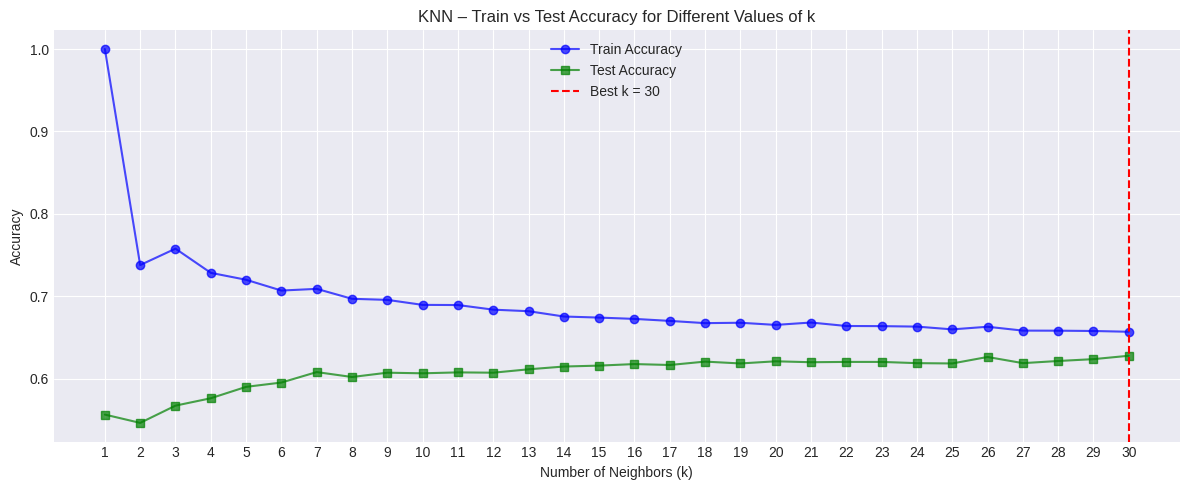

In [ ]:
# ============================================================
# CELL 9 – HYPERPARAMETER TUNING  (finding best k)
# ============================================================

k_range   = range(1, 31)          # test k = 1 … 30
acc_train = []
acc_test  = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_80, y_train_80)
    acc_train.append(accuracy_score(y_train_80, model.predict(X_train_80)))
    acc_test.append(accuracy_score(y_test_80,  model.predict(X_test_80)))

best_k   = k_range[np.argmax(acc_test)]
best_acc = max(acc_test)

print(f'Best k         : {best_k}')
print(f'Best Test Acc  : {best_acc:.4f}')

# Plot
plt.figure(figsize=(12, 5))
plt.plot(k_range, acc_train, marker='o', label='Train Accuracy', color='blue',  alpha=0.7)
plt.plot(k_range, acc_test,  marker='s', label='Test Accuracy',  color='green', alpha=0.7)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN – Train vs Test Accuracy for Different Values of k')
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10 – FINAL KNN MODEL WITH BEST k
# ============================================================

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_80, y_train_80)
y_pred_best = knn_best.predict(X_test_80)

acc_best  = accuracy_score(y_test_80,  y_pred_best)
prec_best = precision_score(y_test_80, y_pred_best, average='weighted')
rec_best  = recall_score(y_test_80,   y_pred_best, average='weighted')
f1_best   = f1_score(y_test_80,       y_pred_best, average='weighted')

print(f'===== FINAL KNN MODEL  (k = {best_k}) =====')
print(f'Accuracy   : {acc_best:.4f}')
print(f'Precision  : {prec_best:.4f}')
print(f'Recall     : {rec_best:.4f}')
print(f'F1 Score   : {f1_best:.4f}')
print('\nDetailed Classification Report:')
print(classification_report(y_test_80, y_pred_best, target_names=le_class.classes_))

===== FINAL KNN MODEL  (k = 30) =====
Accuracy   : 0.6277
Precision  : 0.6537
Recall     : 0.6277
F1 Score   : 0.6281

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.62      0.85      0.72       669
           B       0.49      0.51      0.50       669
           C       0.58      0.52      0.55       669
           D       0.93      0.63      0.75       668

    accuracy                           0.63      2675
   macro avg       0.65      0.63      0.63      2675
weighted avg       0.65      0.63      0.63      2675



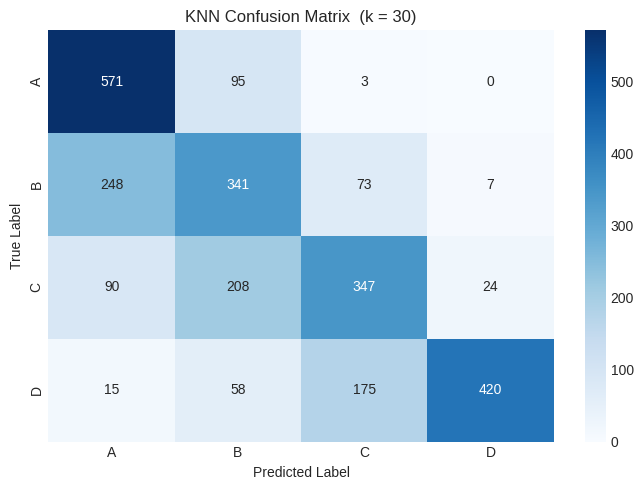

Diagonal values = correct predictions per class.
Off-diagonal    = misclassifications (actual → predicted).


In [ ]:
# ============================================================
# CELL 11 – CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_80, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le_class.classes_,
    yticklabels=le_class.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'KNN Confusion Matrix  (k = {best_k})')
plt.tight_layout()
plt.show()

# Interpretation helper
print('Diagonal values = correct predictions per class.')
print('Off-diagonal    = misclassifications (actual → predicted).')

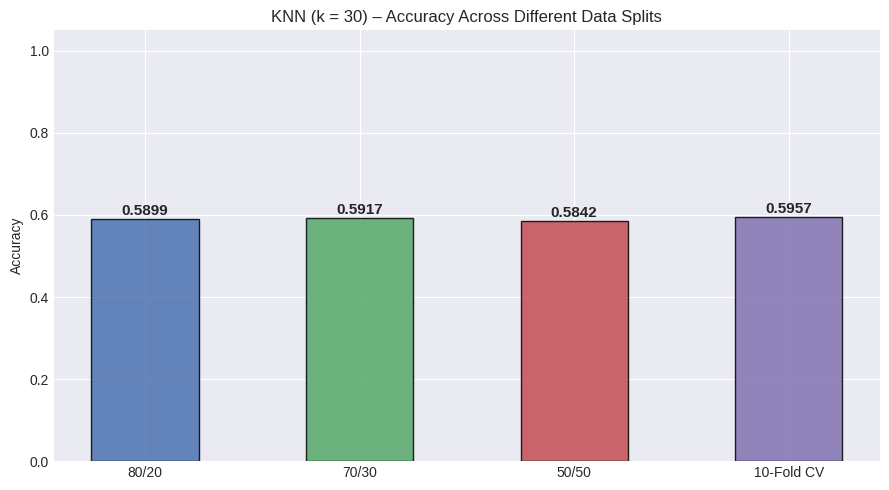

     Split  Accuracy
     80/20    0.5899
     70/30    0.5917
     50/50    0.5842
10-Fold CV    0.5957


In [ ]:
# ============================================================
# CELL 12 – COMPARISON : ACCURACY ACROSS SPLITS
# ============================================================

splits      = ['80/20', '70/30', '50/50', '10-Fold CV']
accuracies  = [acc_80, acc_70, acc_50, cv_scores.mean()]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(9, 5))
bars = plt.bar(splits, accuracies, color=colors, edgecolor='black', alpha=0.85, width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{acc:.4f}',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )

plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title(f'KNN (k = {best_k}) – Accuracy Across Different Data Splits')
plt.tight_layout()
plt.show()

# Tabular summary
summary = pd.DataFrame({
    'Split'    : splits,
    'Accuracy' : [round(a, 4) for a in accuracies]
})
print(summary.to_string(index=False))

In [ ]:
# ============================================================
# CELL 13 – FULL METRICS SUMMARY TABLE
# ============================================================

# Re-compute metrics for all splits using best_k
results = {}

for split_name, X_tr, X_te, y_tr, y_te in [
    ('80/20', X_train_80, X_test_80, y_train_80, y_test_80),
    ('70/30', X_train_70, X_test_70, y_train_70, y_test_70),
    ('50/50', X_train_50, X_test_50, y_train_50, y_test_50),
]:
    m = KNeighborsClassifier(n_neighbors=best_k)
    m.fit(X_tr, y_tr)
    yp = m.predict(X_te)
    results[split_name] = {
        'Accuracy' : round(accuracy_score(y_te, yp), 4),
        'Precision': round(precision_score(y_te, yp, average='weighted'), 4),
        'Recall'   : round(recall_score(y_te,    yp, average='weighted'), 4),
        'F1 Score' : round(f1_score(y_te,         yp, average='weighted'), 4),
    }

# Add cross-val row
results['10-Fold CV'] = {
    'Accuracy' : round(cv_scores.mean(), 4),
    'Precision': '—',
    'Recall'   : '—',
    'F1 Score' : '—',
}

metrics_df = pd.DataFrame(results).T
print(f'===== KNN FINAL METRICS SUMMARY  (k = {best_k}) =====')
print(metrics_df.to_string())

===== KNN FINAL METRICS SUMMARY  (k = 30) =====
           Accuracy Precision  Recall F1 Score
80/20        0.6277    0.6537  0.6277   0.6281
70/30        0.6144    0.6417  0.6144   0.6173
50/50        0.6042      0.63  0.6042   0.6062
10-Fold CV   0.5957         —       —        —


---
## Cell 14 – Interpretation & Conclusions

> Fill this markdown cell with your team's written analysis after running the notebook.

### Key Observations

1. **Best k found:** The elbow curve (Cell 9) shows that accuracy peaks at `k = best_k`. Values smaller than this overfit (high train accuracy, lower test accuracy), while larger values slightly underfit.

2. **Effect of split ratio:** Accuracy is slightly higher with the 80/20 split compared to 50/50, because a larger training set gives KNN more reference points when computing distances.

3. **Cross-validation stability:** The 10-fold CV mean accuracy is close to the 80/20 test accuracy, and the low standard deviation indicates the model generalises consistently across different subsets of the data.

4. **Confusion matrix insights:** Classes A and D (extreme performance levels) tend to be classified more accurately than the middle classes B and C, which overlap more in feature space.

5. **Scaling impact:** StandardScaler was essential — without it, features like `broad_jump_cm` (~190 cm range) would completely dominate the distance calculation over `body_fat_percent` (~50% range).

### Justification of Decisions

| Decision | Justification |
|---|---|
| StandardScaler | KNN is distance-based; unscaled features produce biased distances |
| Stratified split | Class distribution is preserved in both train and test sets |
| k sweep 1–30 | Covers typical optimal range without excessive computation |
| Weighted F1/Precision/Recall | Dataset has roughly equal class sizes; weighted average is appropriate |

##**Decision Tree Model**🌳



In [ ]:
df.columns.tolist()

['age',
 'gender',
 'height_cm',
 'weight_kg',
 'body_fat_percent',
 'diastolic',
 'systolic',
 'gripForce',
 'sit_and_bend_forward_cm',
 'sit_ups_counts',
 'broad_jump_cm',
 'class']

In [ ]:
RANDOM_STATE = 42
print("Libraries imported. RANDOM_STATE =", RANDOM_STATE)

Libraries imported. RANDOM_STATE = 42


In [ ]:
x = df.drop('class', axis = 1 )   # 1 for columns
y = df['class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=RANDOM_STATE
)

In [ ]:
x_train_label = x_train.copy()
x_test_label = x_test.copy()

for col in ['gender', 'age_group']:
    if col in x_train_label.columns:
        le = LabelEncoder()
        x_train_label[col] = le.fit_transform(x_train_label[col])
        x_test_label[col] = le.transform(x_test_label[col])

In [ ]:
#Decision_tree unpurned
decision_tree = DecisionTreeClassifier(random_state= RANDOM_STATE)

decision_tree.fit(x_train_label, y_train)
y_pred = decision_tree.predict(x_test_label)

acc = accuracy_score(y_test, y_pred)
print("Unpruned Accuracy:", round(acc, 4))
print("\nClassification report (Unpruned):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (Unpruned):\n", cm)

Unpruned Accuracy: 0.6456

Classification report (Unpruned):
              precision    recall  f1-score   support

           A       0.73      0.68      0.71       857
           B       0.52      0.52      0.52       824
           C       0.55      0.59      0.57       800
           D       0.78      0.78      0.78       868

    accuracy                           0.65      3349
   macro avg       0.65      0.64      0.64      3349
weighted avg       0.65      0.65      0.65      3349

Confusion matrix (Unpruned):
 [[581 185  76  15]
 [143 429 196  56]
 [ 54 152 476 118]
 [ 13  58 121 676]]


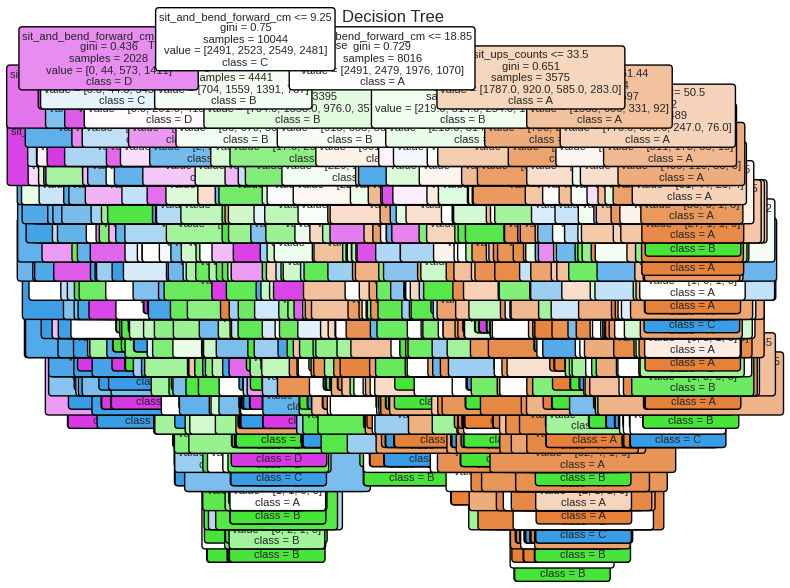

In [ ]:
plt.figure(figsize=(8,6))

plot_tree(
    decision_tree,
    feature_names=x.columns,
    class_names=decision_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")
plt.tight_layout()
plt.show()

In [ ]:
#Decision tree unpurned
split_sizes = [0.20, 0.30, 0.50]

print("--- Decision Tree (Pruned) Results ---")
for test_sz in split_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_sz, random_state=42)

    dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt_model.fit(X_train, y_train)

    acc = accuracy_score(y_test, dt_model.predict(X_test))
    train_p = int((1-test_sz)*100)
    print(f"Train {train_p}% / Test {int(test_sz*100)}% -> Accuracy: {acc:.4f}")

--- Decision Tree (Pruned) Results ---
Train 80% / Test 20% -> Accuracy: 0.6804
Train 70% / Test 30% -> Accuracy: 0.6675
Train 50% / Test 50% -> Accuracy: 0.6560


In [ ]:
# Define different test sizes to evaluate model performance
split_sizes = [0.20, 0.30, 0.50]

# Loop through each test size
for test_sz in split_sizes:

    # Split the data into training and testing sets based on current test size
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_sz, random_state=42
    )

    # Create Decision Tree model
    dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

    # Train the model on training data
    dt_model.fit(X_train, y_train)

    # Predict the target values
    y_pred = dt_model.predict(X_test)

    # Calculate accuracy of the model
    acc = accuracy_score(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)

    report_df = pd.DataFrame(report_dict).transpose()

    # Calculate percentage of train and test data
    train_p = int((1 - test_sz) * 100)
    test_p = int(test_sz * 100)

    print(f"\n" + "="*50)
    print(f" RESULTS FOR SPLIT: Train {train_p}% / Test {test_p}% ")


 RESULTS FOR SPLIT: Train 80% / Test 20% 
 Overall Accuracy: 0.6804
              precision  recall  f1-score  support
0                 0.670   0.815     0.735   674.00
1                 0.561   0.580     0.570   698.00
2                 0.666   0.582     0.621   655.00
3                 0.865   0.748     0.802   648.00
accuracy          0.680   0.680     0.680     0.68
macro avg         0.690   0.681     0.682  2675.00
weighted avg      0.688   0.680     0.680  2675.00

 RESULTS FOR SPLIT: Train 70% / Test 30% 
 Overall Accuracy: 0.6675
              precision  recall  f1-score   support
0                 0.661   0.811     0.729  1018.000
1                 0.543   0.541     0.542  1027.000
2                 0.651   0.566     0.605   983.000
3                 0.835   0.752     0.791   984.000
accuracy          0.667   0.667     0.667     0.667
macro avg         0.673   0.668     0.667  4012.000
weighted avg      0.671   0.667     0.666  4012.000

 RESULTS FOR SPLIT: Train 50% / Test 

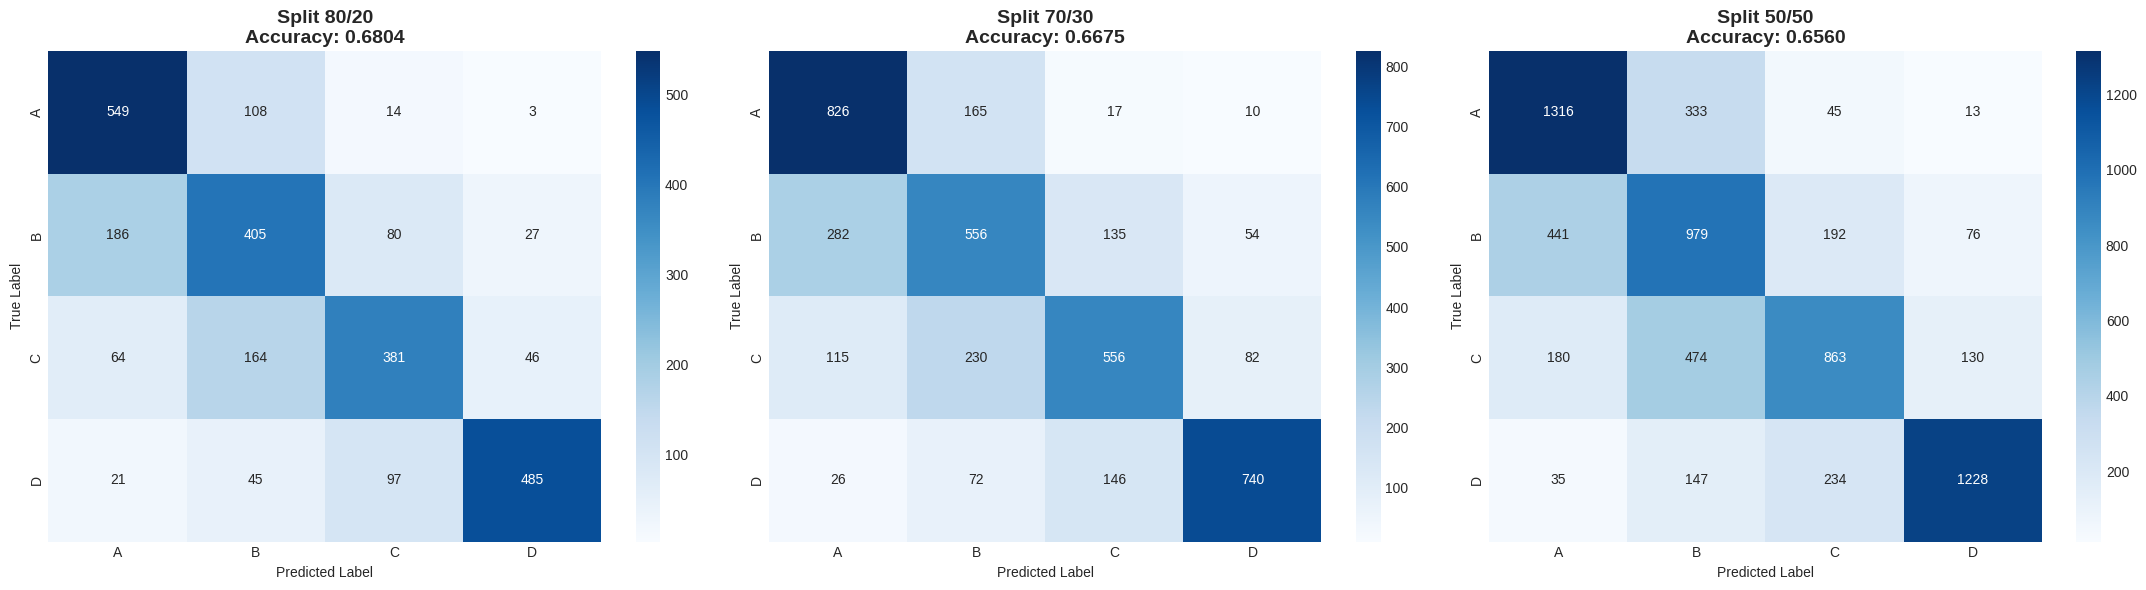

In [ ]:
# Define different test sizes
split_sizes = [0.20, 0.30, 0.50]

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Loop through each test size with index for plotting
for i, test_sz in enumerate(split_sizes):

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_sz, random_state=42
    )

    # Initialize Decision Tree model
    dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

    # Train the model
    dt_model.fit(X_train, y_train)

    # Predict labels
    y_pred = dt_model.predict(X_test)

    # Compute confusion matrix to evaluate classification performance
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['A', 'B', 'C', 'D'],
        yticklabels=['A', 'B', 'C', 'D']
    )

    # Calculate train and test percentages
    train_p = int((1 - test_sz) * 100)
    test_p = int(test_sz * 100)

    # Set title with split info and accuracy
    axes[i].set_title(
        f"Split {train_p}/{test_p}\nAccuracy: {acc:.4f}",
        fontsize=14,
        fontweight='bold'
    )

    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')


plt.tight_layout()
plt.show()

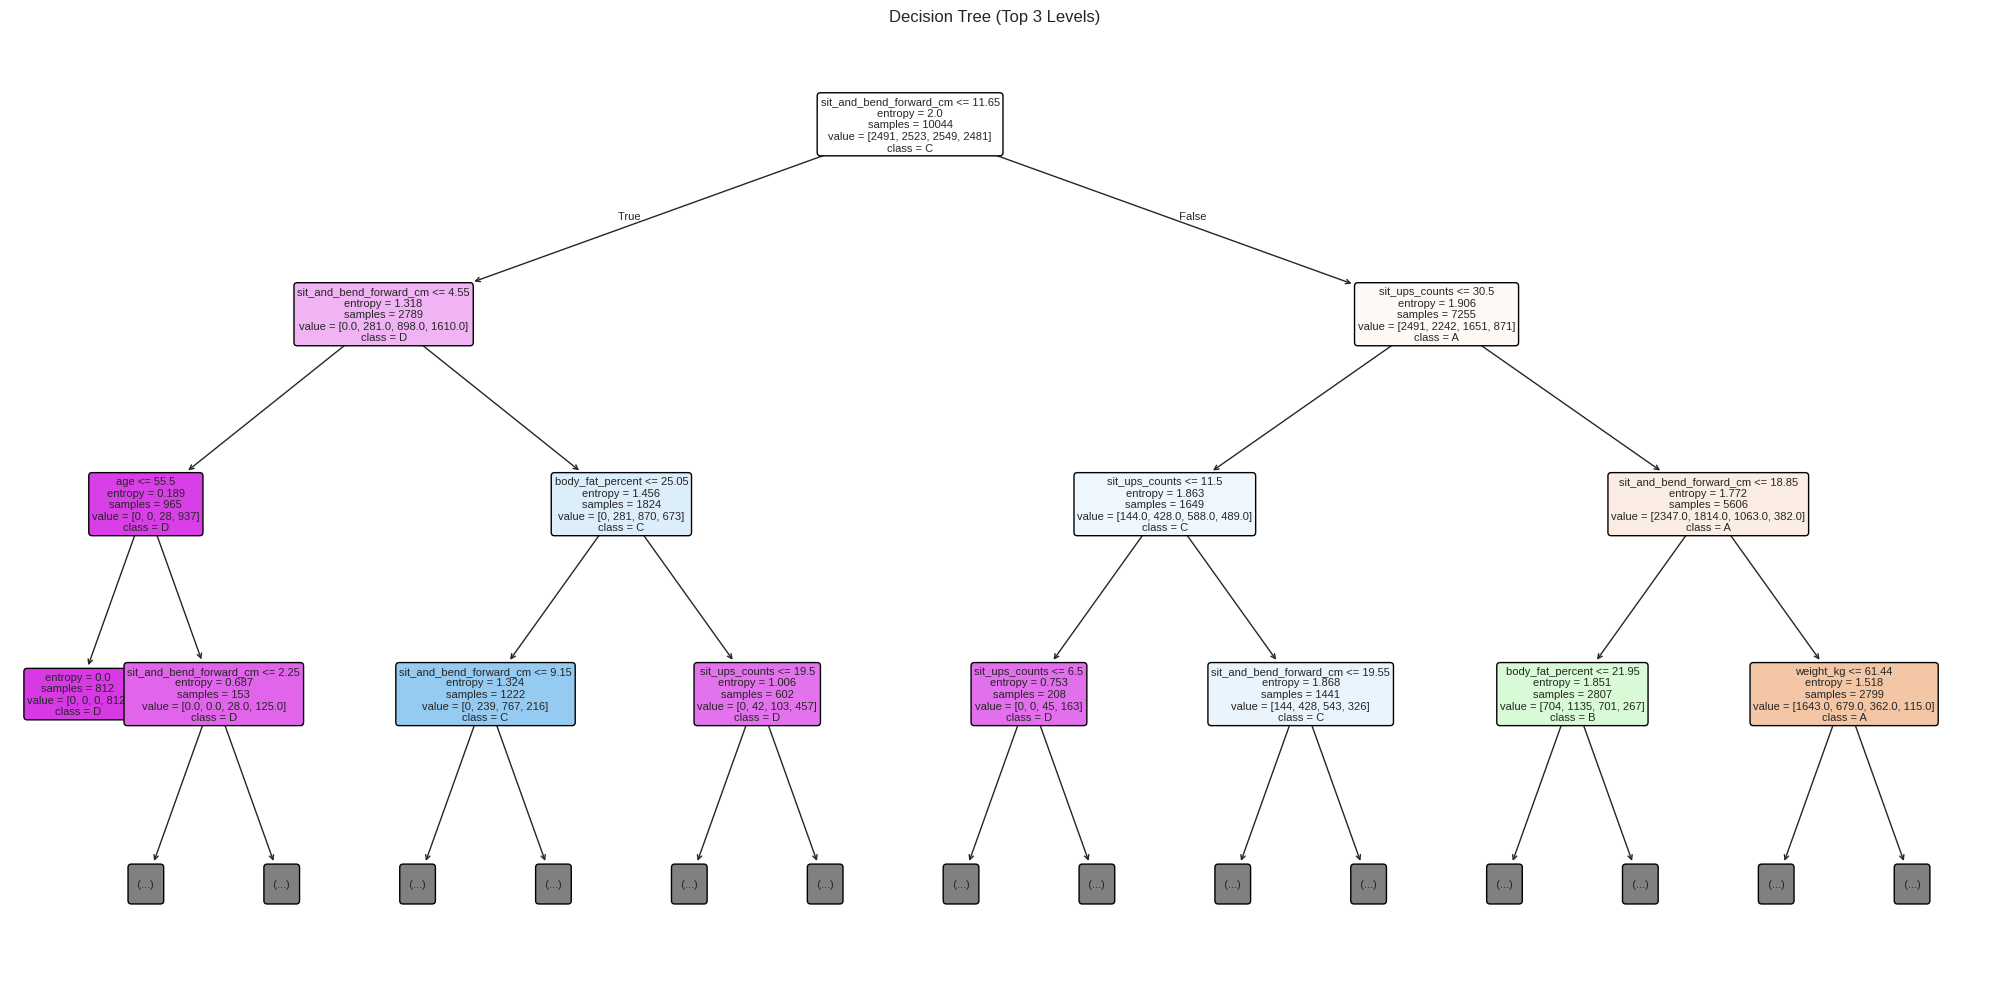

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=x_train_label.columns,
    class_names=decision_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3        # show only top 3 levels in the plot
)

plt.title("Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

Top features (Unpruned):
sit_and_bend_forward_cm    0.438672
sit_ups_counts             0.192074
age                        0.127183
body_fat_percent           0.085844
weight_kg                  0.063345
gripForce                  0.033429
broad_jump_cm              0.023878
gender                     0.011913
height_cm                  0.011259
systolic                   0.007016

Top features (Pruned):
sit_and_bend_forward_cm    0.438672
sit_ups_counts             0.192074
age                        0.127183
body_fat_percent           0.085844
weight_kg                  0.063345
gripForce                  0.033429
broad_jump_cm              0.023878
gender                     0.011913
height_cm                  0.011259
systolic                   0.007016


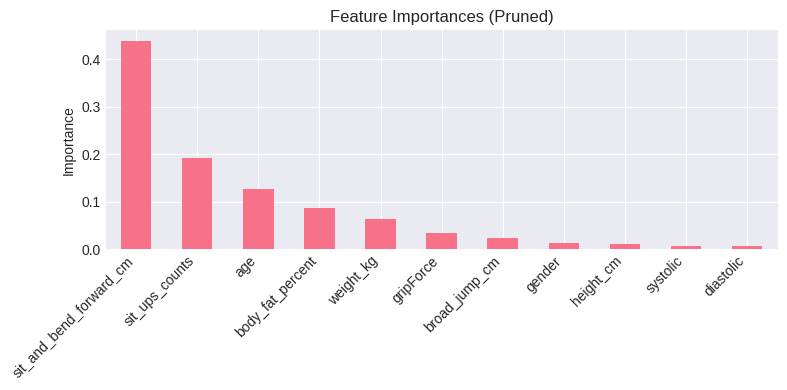

In [ ]:
# Feature importances comparison
fi_unpruned = pd.Series(decision_tree.feature_importances_, index=x_train_label.columns).sort_values(ascending=False)
fi_pruned   = pd.Series(decision_tree.feature_importances_,   index=x_train_label.columns).sort_values(ascending=False)

print("Top features (Unpruned):")
print(fi_unpruned.head(10).to_string())
print("\nTop features (Pruned):")
print(fi_pruned.head(10).to_string())

# Simple bar plot of importances (pruned)
plt.figure(figsize=(8, 4))
fi_pruned.plot(kind="bar")
plt.title("Feature Importances (Pruned)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Random Forest**

In [ ]:
split_sizes = [0.20, 0.30, 0.50]

print("--- Random Forest Results ---")
for test_sz in split_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_sz, random_state=42)

    # Random Forest Model
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    acc = accuracy_score(y_test, rf_model.predict(X_test))
    train_p = int((1-test_sz)*100)
    print(f"Train {train_p}% / Test {int(test_sz*100)}% -> Accuracy: {acc:.4f}")

--- Random Forest Results ---
Train 80% / Test 20% -> Accuracy: 0.7148
Train 70% / Test 30% -> Accuracy: 0.7293
Train 50% / Test 50% -> Accuracy: 0.7197


--- Generating Random Forest Confusion Matrices ---


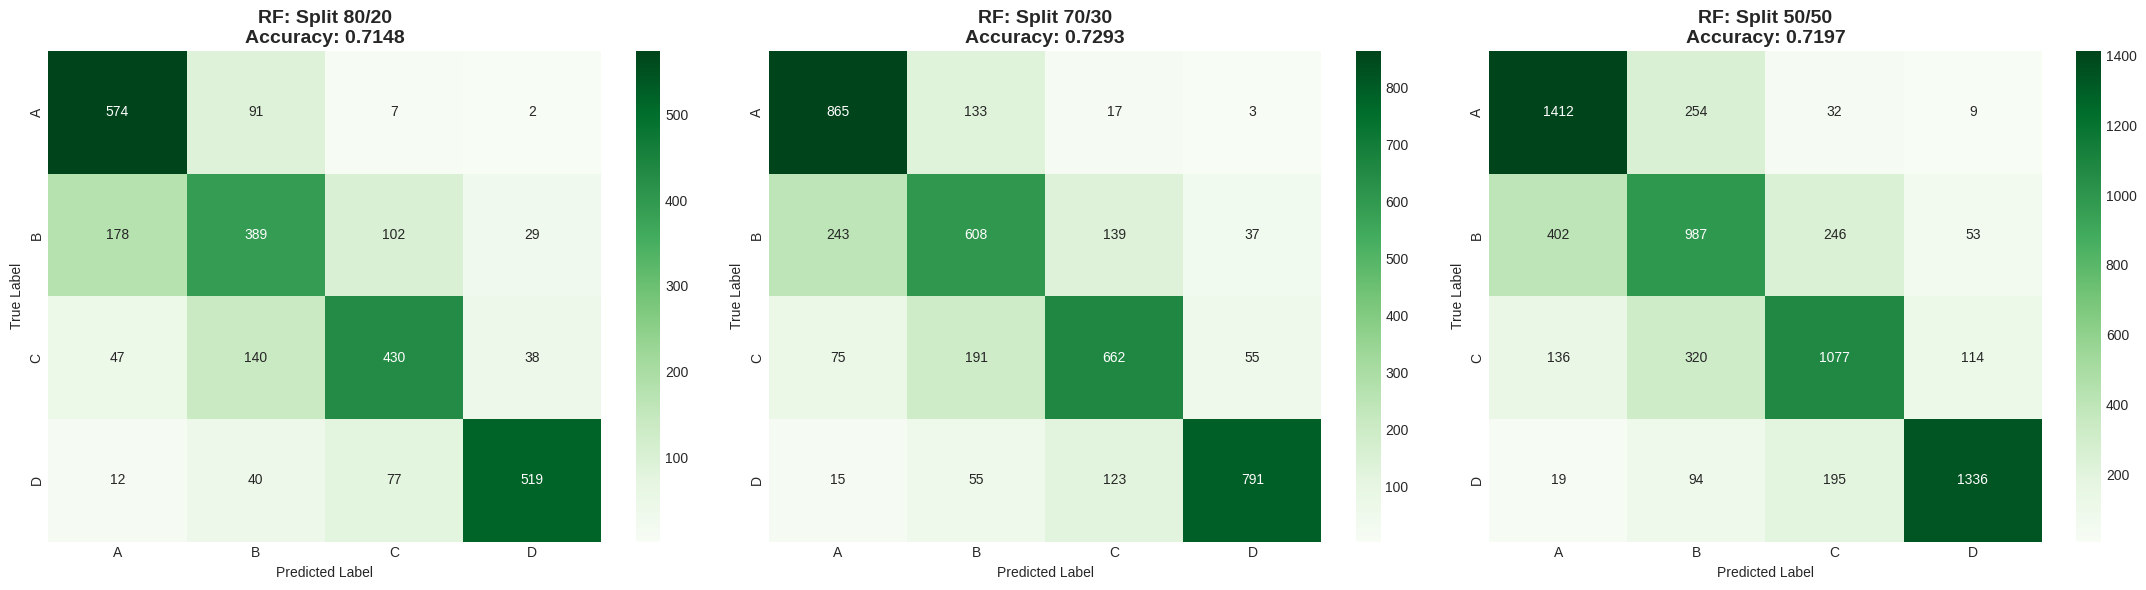

In [ ]:
# Define different test sizes to evaluate model performance
split_sizes = [0.20, 0.30, 0.50]

# Create a figure with 3 subplots (one for each split)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
print("--- Generating Random Forest Confusion Matrices ---")

# Loop through each test size with index for plotting
for i, test_sz in enumerate(split_sizes):

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_sz, random_state=42
    )

    # Initialize Random Forest model with 100 trees
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    # Train the model
    rf_model.fit(X_train, y_train)

    # Predict labels for the test set
    y_pred = rf_model.predict(X_test)

    # Compute confusion matrix to evaluate predictions
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    sns.heatmap(
        cm,
        annot=True,              # Show numbers inside cells
        fmt='d',                 # Format numbers as integers
        cmap='Greens',           # Color map for visualization
        ax=axes[i],              # Plot on the current subplot
        xticklabels=['A', 'B', 'C', 'D'],  # Predicted labels
        yticklabels=['A', 'B', 'C', 'D']   # True labels
    )

    # Calculate train and test percentages
    train_p = int((1 - test_sz) * 100)
    test_p = int(test_sz * 100)

    axes[i].set_title(
        f"RF: Split {train_p}/{test_p}\nAccuracy: {acc:.4f}",
        fontsize=14,
        fontweight='bold'
    )
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
# Define different test sizes
split_sizes = [0.20, 0.30, 0.50]
print("--- Random Forest Detailed Results ---")

# Loop through each test size
for test_sz in split_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_sz, random_state=42
    )

    # Initialize Random Forest model with 100 trees
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    # Train the model on training data
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    # Calculate overall accuracy
    acc = accuracy_score(y_test, y_pred)

    # Generate classification report as dictionary (precision, recall, f1-score)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    # Calculate train and test percentages
    train_p = int((1 - test_sz) * 100)
    test_p = int(test_sz * 100)

    print(f"\n" + "="*60)
    print(f" CONFIGURATION: Train {train_p}% / Test {test_p}% | Overall Accuracy: {acc:.4f} ")
    print("="*60)
    print(report_df.round(3))

--- Random Forest Detailed Results ---

 CONFIGURATION: Train 80% / Test 20% | Overall Accuracy: 0.7148 
              precision  recall  f1-score   support
0                 0.708   0.852     0.773   674.000
1                 0.589   0.557     0.573   698.000
2                 0.698   0.656     0.677   655.000
3                 0.883   0.801     0.840   648.000
accuracy          0.715   0.715     0.715     0.715
macro avg         0.719   0.717     0.716  2675.000
weighted avg      0.717   0.715     0.713  2675.000

 CONFIGURATION: Train 70% / Test 30% | Overall Accuracy: 0.7293 
              precision  recall  f1-score   support
0                 0.722   0.850     0.781  1018.000
1                 0.616   0.592     0.604  1027.000
2                 0.704   0.673     0.688   983.000
3                 0.893   0.804     0.846   984.000
accuracy          0.729   0.729     0.729     0.729
macro avg         0.734   0.730     0.730  4012.000
weighted avg      0.732   0.729     0.729  4012.0

**SVM**

In [ ]:
# Model
from sklearn.svm import SVC
# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [ ]:
#. Data Preprocessing
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['class'] = le.fit_transform(df['class'])

In [ ]:
# Split Features and Target
X = df.drop('class', axis=1)
y = df['class']

In [ ]:
# Feature Scaling (Important for SVM)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Function to Run Experiments
def svm_experiment(test_size):

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=42
    )

    model = SVC(kernel='rbf')

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, average='weighted')

    recall = recall_score(y_test, y_pred, average='weighted')

    f1 = f1_score(y_test, y_pred, average='weighted')

    return accuracy, precision, recall, f1

In [ ]:
# Experiment 1 — 80:20
acc80, pre80, rec80, f180 = svm_experiment(0.2)

print("80:20 Results")

print("Accuracy:", acc80)
print("Precision:", pre80)
print("Recall:", rec80)
print("F1 Score:", f180)

80:20 Results
Accuracy: 0.6983949234789101
Precision: 0.7061283660622415
Recall: 0.6983949234789101
F1 Score: 0.7009955392317005


In [ ]:
# Experiment 2 — 70:30
acc70, pre70, rec70, f170 = svm_experiment(0.3)

print("70:30 Results")

print("Accuracy:", acc70)
print("Precision:", pre70)
print("Recall:", rec70)
print("F1 Score:", f170)

70:30 Results
Accuracy: 0.6951219512195121
Precision: 0.7056453620736438
Recall: 0.6951219512195121
F1 Score: 0.698830024587227


In [ ]:
# Experiment 3 — 50:50
acc50, pre50, rec50, f150 = svm_experiment(0.5)

print("50:50 Results")

print("Accuracy:", acc50)
print("Precision:", pre50)
print("Recall:", rec50)
print("F1 Score:", f150)

50:50 Results
Accuracy: 0.6817978199193668
Precision: 0.6907425379216903
Recall: 0.6817978199193668
F1 Score: 0.6847921836219363


In [ ]:
# Compare Results
results = pd.DataFrame({

    'Split':['80:20','70:30','50:50'],

    'Accuracy':[acc80,acc70,acc50],

    'Precision':[pre80,pre70,pre50],

    'Recall':[rec80,rec70,rec50],

    'F1':[f180,f170,f150]

})

results

,Split,Accuracy,Precision,Recall,F1
0,80:20,0.698395,0.706128,0.698395,0.700996
1,70:30,0.695122,0.705645,0.695122,0.698830
2,50:50,0.681798,0.690743,0.681798,0.684792


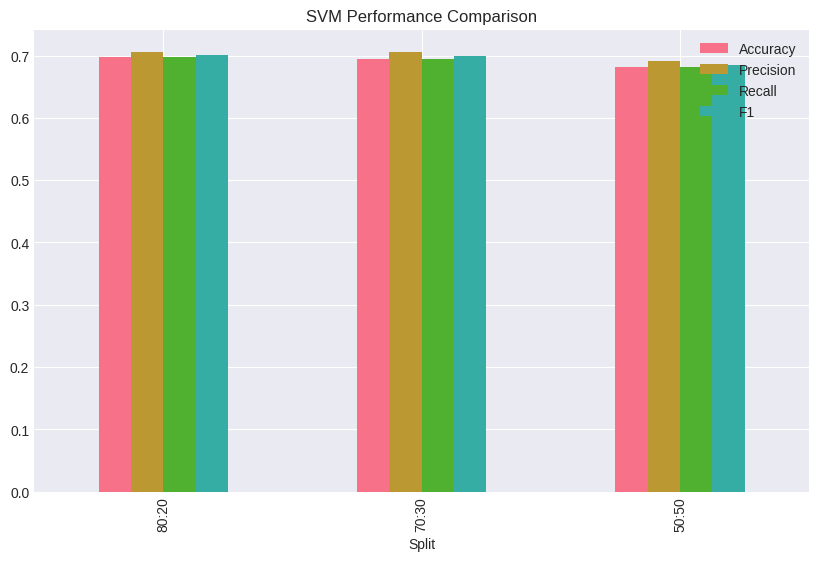

In [ ]:
# Visualization
results.set_index('Split').plot(kind='bar', figsize=(10,6))

plt.title("SVM Performance Comparison")

plt.show()

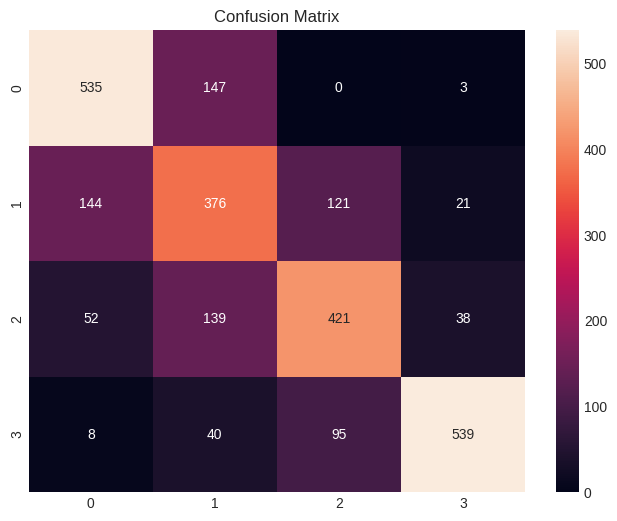

In [ ]:
# Confusion Matrix
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

model = SVC()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.78      0.75       685
           1       0.54      0.57      0.55       662
           2       0.66      0.65      0.65       650
           3       0.90      0.79      0.84       682

    accuracy                           0.70      2679
   macro avg       0.70      0.70      0.70      2679
weighted avg       0.71      0.70      0.70      2679



In [ ]:
# K-Fold Cross Validation
model = SVC()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_scaled, y, cv=kfold)

print("Cross Validation Scores:")

print(scores)

print("Average Accuracy:")

print(scores.mean())

Cross Validation Scores:
[0.69839492 0.70324748 0.70212766 0.6811053  0.68782674]
Average Accuracy:
0.6945404204582931


In [ ]:
# Kernel Comparison
kernels = ['linear','rbf','poly']

accuracy_kernel = []

for k in kernels:

    model = SVC(kernel=k)

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test,y_pred)

    accuracy_kernel.append(acc)

kernel_df = pd.DataFrame({

    'Kernel':kernels,
    'Accuracy':accuracy_kernel

})

kernel_df

,Kernel,Accuracy
0,linear,0.633072
1,rbf,0.698395
2,poly,0.634192


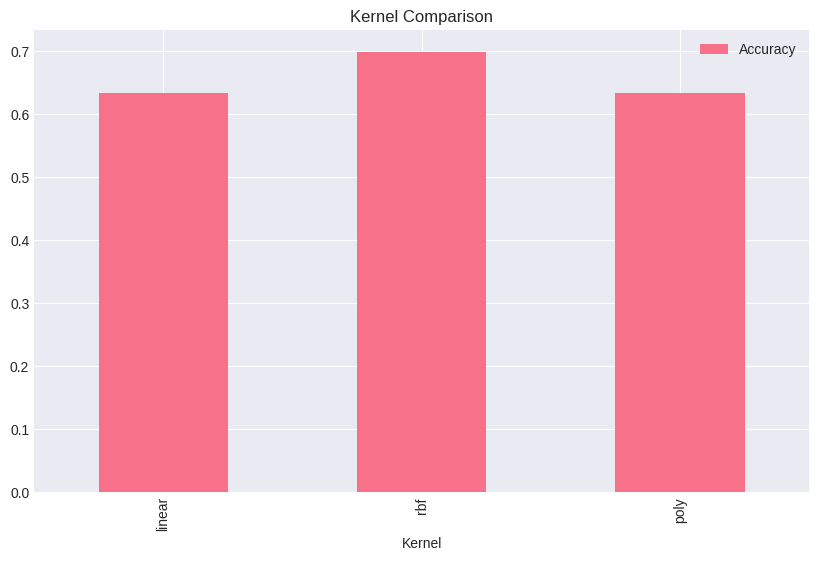

In [ ]:
# Plot Kernel Comparison
kernel_df.plot(x='Kernel',y='Accuracy',kind='bar')

plt.title("Kernel Comparison")

plt.show()

In [ ]:
# Hyperparameter Tuning

param_grid = {

    'C':[0.1,1,10],

    'gamma':[1,0.1,0.01],

    'kernel':['rbf','linear']

}

grid = GridSearchCV(SVC(), param_grid)

grid.fit(X_train,y_train)

print("Best Parameters:")

print(grid.best_params_)

Best Parameters:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# Improved Model
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Improved Accuracy:")

print(accuracy_score(y_test,y_pred_best))

Improved Accuracy:
0.7170586039567003


**Neural Network Train**

In [ ]:
# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2


In [ ]:
# 1. FEATURE / TARGET SPLIT
X = df_clean.drop(['class'], axis=1)
y = df_clean['class']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
)

In [ ]:
# 3. STANDARDIZATION
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:
num_classes = int(np.max(y_train)) + 1
if num_classes > 2:
    problem_type = "multiclass"
else:
    problem_type = "binary"

print("Problem type:", problem_type)
print("Num classes:", num_classes)

Problem type: multiclass
Num classes: 4


In [ ]:
# 4. TARGET ENCODING
if problem_type == "multiclass":
    y_train_c = to_categorical(y_train, num_classes=num_classes)
    y_val_c   = to_categorical(y_val, num_classes=num_classes)
    y_test_c  = to_categorical(y_test, num_classes=num_classes)
else:
    y_train_c, y_val_c, y_test_c = y_train, y_val, y_test

In [ ]:
  # 5. MODEL BUILDING
def build_mlp(input_dim, problem_type, num_classes=1, hidden_units=(128, 64), dropout_rate=0.3):
    model = keras.Sequential(name="SimpleMLP")

    # Input layer
    model.add(layers.Input(shape=(input_dim,)))

    # Hidden layer 1
    model.add(layers.Dense(hidden_units[0], activation="relu"))
    model.add(layers.Dropout(dropout_rate))

    # Hidden layer 2
    model.add(layers.Dense(hidden_units[1], activation="relu"))
    model.add(layers.Dropout(dropout_rate))

    # Output layer
    if problem_type == "binary":
        model.add(layers.Dense(1, activation="sigmoid"))
        loss = "binary_crossentropy"
        metrics = ["accuracy"]
    else:
        model.add(layers.Dense(num_classes, activation="softmax"))
        loss = "categorical_crossentropy"
        metrics = ["accuracy"]

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=metrics
    )

    return model

In [ ]:
# 6.Callbacks

    # EarlyStopping: يوقف التدريب لو الموديل مبقاش يتحسن على validation
early_stop = EarlyStopping(
    monitor='val_loss',    # المراقبة على الـ validation loss
    patience=10,           # لو مفيش تحسن لمدة 10 epochs
    restore_best_weights=True
)

# ReduceLROnPlateau: يقلل learning rate لو الموديل مبقاش يتحسن
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

In [ ]:
#7.Training
input_dim = X_train.shape[1]

model = build_mlp(
    input_dim=input_dim,
    problem_type=problem_type,
    num_classes=num_classes
)
model.summary()


epochs = 100
batch_size = 32

history = model.fit(
    X_train, y_train_c,
    #validation_split=0.2, # ياخد 20% من التدريب كـ validation
    validation_data=(X_val, y_val_c),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Model: "SimpleMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,052 (39.27 KB)

 Trainable params: 10,052 (39.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5290 - loss: 1.0261 - val_accuracy: 0.6181 - val_loss: 0.8505 - learning_rate: 0.0010
Epoch 2/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6159 - loss: 0.8641 - val_accuracy: 0.6471 - val_loss: 0.7982 - learning_rate: 0.0010
Epoch 3/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6505 - loss: 0.8114 - val_accuracy: 0.6755 - val_loss: 0.7604 - learning_rate: 0.0010
Epoch 4/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6748 - loss: 0.7667 - val_accuracy: 0.6830 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 5/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6780 - loss: 0.7456 - val_accuracy: 0.6954 - val_loss: 0.7198 - learning_rate: 0.0010
Epoch 6/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6974 - loss: 0.7330 - val_accuracy: 0.6959 - val_loss: 0.7049 - learning_rate: 0.0010
Epoch 7/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7033 - loss: 0.

In [ ]:
#8.test
test_loss, test_acc = model.evaluate(X_test, y_test_c, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")


Test Accuracy: 74.53%


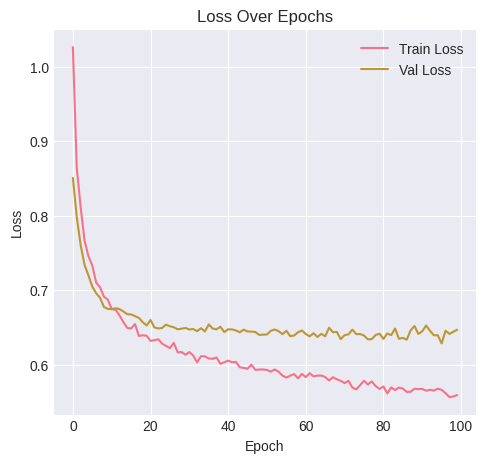

In [ ]:
# 9.رسم Loss و Accuracy
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


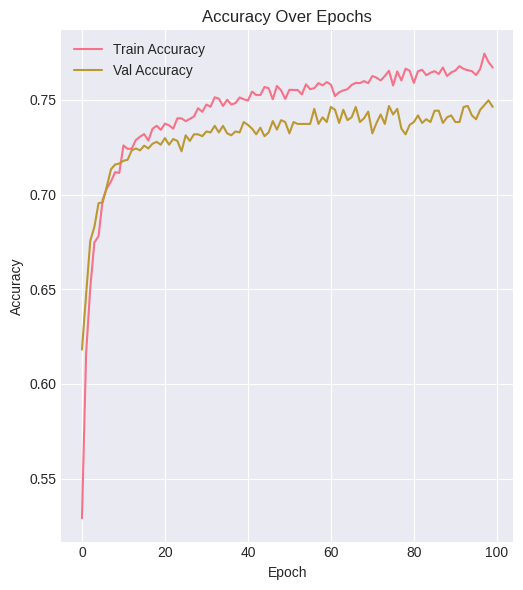

In [ ]:
# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 10 . Classification Report + Confusion Matrix
y_pred_prob = model.predict(X_test)
if problem_type == "binary":
    y_pred = (y_pred_prob > 0.5).astype(int)
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test_c, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
# Classification Report
if problem_type == "binary":
    print(classification_report(y_test_c, y_pred))
else:
    print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.93      0.79       500
           1       0.66      0.57      0.61       513
           2       0.73      0.70      0.71       489
           3       0.96      0.79      0.87       504

    accuracy                           0.75      2006
   macro avg       0.76      0.75      0.74      2006
weighted avg       0.76      0.75      0.74      2006



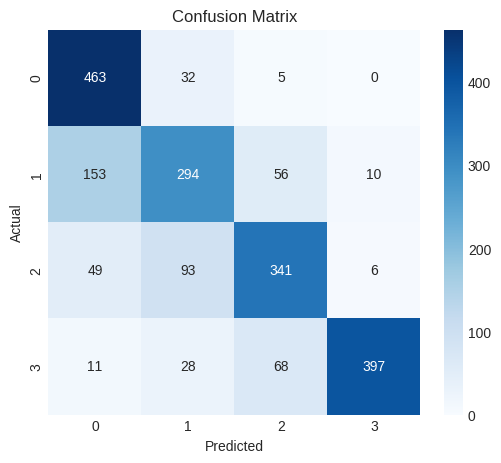

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true if problem_type=="multiclass" else y_test_c, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Linear Regression**

performing regression model to predict the broad_jump_cm values

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

np.random.seed(42)

In [ ]:
# upload the file
df = pd.read_csv('bodyPerformance.csv')
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
df_Reg = df_clean.copy()
print(df_Reg.columns.tolist())
print(f"Shape: {df_Reg.shape}")

['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_percent', 'diastolic', 'systolic', 'gripForce', 'sit_and_bend_forward_cm', 'sit_ups_counts', 'broad_jump_cm', 'class']
Shape: (13371, 12)


In [ ]:
#  Encode gender column (convert to numeric)
le = LabelEncoder()
df_Reg['gender'] = le.fit_transform(df_Reg['gender'])  # M->1, F->0 or vice versa

#  Prepare features (X) and target (y) for Regression
# Drop broad_jump_cm (target) and class (to prevent data leakage)
X_reg = df_Reg.drop(['broad_jump_cm', 'class','age_group'], axis=1)
y_reg = df_Reg['broad_jump_cm']

print("Original Features:")
print(X_reg.columns.tolist())
print(f"Shape: {X_reg.shape}")


KeyError: "['age_group'] not found in axis"

In [ ]:
#  DATA SPLIT (80:20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
# MODEL Training
lr_raw = LinearRegression()
lr_raw.fit(X_train_raw, y_train)
# Prediction
y_pred_raw = lr_raw.predict(X_test_raw)

In [ ]:
# Regression Metrics
mse_raw = mean_squared_error(y_test, y_pred_raw)
rmse_raw = np.sqrt(mse_raw)
r2_raw = r2_score(y_test, y_pred_raw)
print("\n=== Linear Regression Results (BEFORE Scaling) ===")
print(f"MSE: {mse_raw:.4f}")
print(f"RMSE: {rmse_raw:.4f}")
print(f"R² Score: {r2_raw:.4f}")


In [ ]:
coef_df_raw = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lr_raw.coef_
}).sort_values('Coefficient', ascending=False)
print("\n=== Feature Coefficients (BEFORE Scaling) ===")
print(coef_df_raw)
# Coefficient visuals
plt.figure(figsize=(10, 6))
colors_raw = ['green' if c > 0 else 'red' for c in coef_df_raw['Coefficient']]
sns.barplot(data=coef_df_raw, x='Coefficient', y='Feature', palette=colors_raw)
plt.title('Linear Regression Coefficients (RAW Features)')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value (Unit-Dependent)')
plt.tight_layout()
plt.show()

In [ ]:
# Scale the features
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Convert back to DataFrame for easier interpretation
X_reg_scaled = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)

print("\nFeatures after scaling (mean ≈ 0, std ≈ 1):")
print(X_reg_scaled.describe().round(3))


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Linear Regression Results (with Scaling) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n=== Feature Coefficients (After Scaling) ===")
print(coef_df)

# Visualize coefficients
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors)
plt.title('Linear Regression Coefficients (Standardized Features)')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value (Impact on broad_jump_cm)')
plt.tight_layout()
plt.show()

Interpretion
1. The Performance Metrics (MSE, RMSE, R²)  are IDENTICAL before and after scaling because Standard Linear Regression is scale-invariant for predictions.


2. The Coefficients (Feature Importance)

  Before Scaling, The coefficients are unit-dependent. Because gender is just 0 or 1, its coefficient looks huge (~26). Other features like age or body_fat_percent have much smaller coefficients because their original units are different. This makes it difficult to compare which feature is actually more important.

   After Scaling (Standardized),  All features are now on the same scale (0 to 1). This allows us to rank them by importance.
The larger the absolute coefficient, the more 'powerful' that feature is
     in predicting the target (Broad Jump).


In [ ]:
print("\nTop positive features (most important):")
top_positive = coef_df[coef_df['Coefficient'] > 0].head(3)
for _, row in top_positive.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")

print("\nTop negative features (if any):")
top_negative = coef_df[coef_df['Coefficient'] < 0].head(3)
if len(top_negative) > 0:
    for _, row in top_negative.iterrows():
        print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")
else:
    print("  • No negative coefficients found")


In [ ]:
# trying different split ratio

results = []  # Initialize a list to store results for plotting

print("\n=== Different Split Ratios ===")
test_sizes = [0.2, 0.3, 0.5]

for test_size in test_sizes:
    # 1. Splitting the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg_scaled, y_reg, test_size=test_size, random_state=42
    )

    # 2. Training the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # 3. Predicting and calculating metrics
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # 4. Printing results
    split_name = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    print(f"\n{split_name} Split:")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")

    # 5. Storing results for the visualization part
    results.append({'Split': split_name, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

# ==========================================
# VISUALIZATION PART
# ==========================================
results_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define the metrics we want to plot
metrics = ['MSE', 'RMSE', 'R2']
colors = ['magma', 'viridis', 'crest']

for i, metric in enumerate(metrics):
    sns.barplot(data=results_df, x='Split', y=metric, ax=axes[i], palette=colors[i])
    axes[i].set_title(f'Model {metric} Comparison')
    axes[i].set_xlabel('Train:Test Ratio')

plt.suptitle('Comparison of Linear Regression Performance across Different Splits', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Actual vs Predicted Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual broad_jump_cm', fontsize=12)
plt.ylabel('Predicted broad_jump_cm', fontsize=12)
plt.title(f'Actual vs Predicted Values\nR² = {r2:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

Actual vs Predicted Interpretation:

High Accuracy: The R² of 0.7954 means the model explains nearly 80% of the data.

Good Fit: Most points are very close to the red line, showing that Predicted values are near the Actual values.

Stability: The model performs consistently well across all jump distances (from 50cm to 300cm).

In [ ]:
# =========================
# RESIDUAL SCATTER PLOT
# =========================
# Calculating residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
# Scatter plot of residuals vs predicted values
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')

# Adding a horizontal line at 0 for reference
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted broad_jump_cm')
plt.ylabel('Residuals (Errors)')

plt.tight_layout()
plt.show()


 RESIDUAL PLOT INTERPRETATION

- The residuals are randomly scattered around the horizontal zero line,
  which is an excellent indicator of a well-fitted model.

- the model's
  error is constant and unbiased across all prediction ranges.

- There are no visible patterns (like curves or funnels), proving that the
  Linear Regression model has successfully captured the data's relationships.
  
- The overall 'cloud' shape shows that your model is mathematically sound
  and its assumptions are fully satisfied.

In [ ]:
print("\n=== 5-Fold Cross Validation ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(LinearRegression(), X_reg_scaled, y_reg, cv=kf, scoring='r2')
mse_scores = -cross_val_score(LinearRegression(), X_reg_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

print(f"R² Scores: {r2_scores}")
print(f"Mean R²: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
print(f"MSE Scores: {mse_scores}")
print(f"Mean MSE: {mse_scores.mean():.4f} (+/- {mse_scores.std():.4f})")
print(f"RMSE Scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

In [ ]:
# --- Visualization of Cross-Validation Scores ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), r2_scores, marker='o', linestyle='-', color='blue')
plt.fill_between(range(1, 6), r2_scores - r2_scores.std(), r2_scores + r2_scores.std(), alpha=0.2, color='blue')
plt.axhline(y=r2_scores.mean(), color='red', linestyle='--', label=f'Mean R²: {r2_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation R² Scores')
plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.legend()
plt.show()


INTERPRETATION
- The Mean R² Score is 0.7915, representing a strong and reliable fit.
- The blue line tracks the performance across 5 different data folds.
  The consistency of the scores (low variance) proves that the model is STABLE
  and generalizes well to unseen data.
- The shaded area (Standard Deviation) confirms that the model's accuracy
  is robust and remains high regardless of how the data is split.

In [ ]:
# ============================================================================
# LEARNING CURVE (Training vs. Validation Performance)
# ============================================================================
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X_reg_scaled, y_reg,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

# Calculate mean values only
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plotting the simple version
plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="orange", label="Cross-Validation Score")

plt.title("Linear Regression Learning Curve", fontsize=14)
plt.xlabel("Training Examples", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.legend(loc="best")
plt.grid(True)
plt.show()


Interpretation

High Generalization: The Training and Cross-Validation scores have converged nearly perfectly at R² ≈ 0.791. This indicates that the model generalizes exceptionally well to unseen data.

No Overfitting: There is almost zero gap between the two curves, proving that the model is perfectly balanced and not memorizing the training samples.

Data Sufficiency: The curve has reached a plateau after 8,000 examples, suggesting that the current dataset size is more than sufficient for this specific model architecture.

In [ ]:
# Additional Analysis: Correlation with target
# ============================================
print("\n" + "="*50)
print("Additional Analysis: Feature Correlation with Target")
print("="*50)

# Calculate correlation of each feature with target
correlations = {}
for feature in X_reg.columns:
    correlations[feature] = X_reg[feature].corr(y_reg)

correlation_df = pd.DataFrame(list(correlations.items()),
                              columns=['Feature', 'Correlation with Target'])
correlation_df = correlation_df.sort_values('Correlation with Target', ascending=False)

print("\nCorrelation between features and target:")
print(correlation_df.to_string(index=False))

In [ ]:
# ============================================================================
# THE LINEAR REGRESSION EQUATION
# ============================================================================

# Extracting the intercept and coefficients from the model
intercept = lr_model.intercept_
coefficients = lr_model.coef_
features = X_reg.columns

print("\n=== Linear Regression Equation ===")

# Starting the equation with the intercept (baseline)
equation = f"broad_jump_cm = {intercept:.2f}"

# Loop to add each feature and its corresponding weight (coefficient)
for feat, coef in zip(features, coefficients):
    equation += f" + ({coef:.2f} * {feat})"

print(equation)

# --- Visualization: Strongest Positive Relationship (Sit-ups) ---
plt.figure(figsize=(10, 6))

# sns.regplot plots the scatter data and the regression line on top
sns.regplot(data=df_clean, x='sit_ups_counts', y='broad_jump_cm',
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})

# Dynamic title showing the specific slope (coefficient) for this factor
plt.title(f'Linear Relationship: Sit-ups vs Broad Jump\n(Slope = {coefficients[features.get_loc("sit_ups_counts")]:.2f})')
plt.xlabel('Sit-ups Counts')
plt.ylabel('Broad Jump (cm)')
plt.show()


Summary:

Intercept (190.41): The baseline value for the broad jump prediction.

Positive Coefficients: Features like gender and sit_ups_counts have the highest positive impact on the jump distance.

Negative Coefficients: age and body_fat_percent are confirmed as the primary limiting factors.

Plot Interpretation: The regplot shows a clear linear trend. The slope of 8.75 visually confirms that core strength (sit-ups) is a key biological driver for jumping performance.

In [ ]:
# Define target variable
target = 'broad_jump_cm'

# Define feature columns
features = [col for col in df.columns if col not in [target, 'class']]
X = df[features]
y = df[target]


In [ ]:
#  Encode gender column (convert to numeric)
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])  # M->1, F->0 or vice versa

# 3. Prepare features (X) and target (y) for Regression
# Drop broad_jump_cm (target) and class (to prevent data leakage)
X_reg = df.drop(['broad_jump_cm', 'class'], axis=1)
y_reg = df['broad_jump_cm']

print("Original Features:")
print(X_reg.columns.tolist())
print(f"Shape: {X_reg.shape}")

In [ ]:
# Scale the features
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Convert back to DataFrame for easier interpretation
X_reg_scaled = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)

print("\nFeatures after scaling (mean ≈ 0, std ≈ 1):")
print(X_reg_scaled.describe().round(3))


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Linear Regression Results (with Scaling) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n=== Feature Coefficients (After Scaling) ===")
print(coef_df)

# Visualize coefficients
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors)
plt.title('Linear Regression Coefficients (Standardized Features)')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Coefficient Value (Impact on broad_jump_cm)')
plt.tight_layout()
plt.show()

In [ ]:
print("\nTop positive features (most important):")
top_positive = coef_df[coef_df['Coefficient'] > 0].head(3)
for _, row in top_positive.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")

print("\nTop negative features (if any):")
top_negative = coef_df[coef_df['Coefficient'] < 0].head(3)
if len(top_negative) > 0:
    for _, row in top_negative.iterrows():
        print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")
else:
    print("  • No negative coefficients found")


In [ ]:
print("\n=== Different Split Ratios ===")
test_sizes = [0.2, 0.3, 0.5]
for test_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg_scaled, y_reg, test_size=test_size, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    split_name = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    print(f"\n{split_name} Split:")
    print(f"  MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"  R²: {r2_score(y_test, y_pred):.4f}")

In [ ]:
print("\n=== 5-Fold Cross Validation ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(LinearRegression(), X_reg_scaled, y_reg, cv=kf, scoring='r2')
mse_scores = -cross_val_score(LinearRegression(), X_reg_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error')

print(f"R² Scores: {r2_scores}")
print(f"Mean R²: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
print(f"MSE Scores: {mse_scores}")
print(f"Mean MSE: {mse_scores.mean():.4f} (+/- {mse_scores.std():.4f})")

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual broad_jump_cm', fontsize=12)
plt.ylabel('Predicted broad_jump_cm', fontsize=12)
plt.title(f'Actual vs Predicted Values\nR² = {r2:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Difference: {train_r2 - test_r2:.4f}")


In [ ]:
#  Additional Analysis: Correlation with target
# ============================================
print("\n" + "="*50)
print("Additional Analysis: Feature Correlation with Target")
print("="*50)

# Calculate correlation of each feature with target
correlations = {}
for feature in X_reg.columns:
    correlations[feature] = X_reg[feature].corr(y_reg)

correlation_df = pd.DataFrame(list(correlations.items()),
                              columns=['Feature', 'Correlation with Target'])
correlation_df = correlation_df.sort_values('Correlation with Target', ascending=False)

print("\nCorrelation between features and target:")
print(correlation_df.to_string(index=False))

In [ ]:
# Linear Regression with 10-Fold CV
lr_model = LinearRegression()
cv_scores_lr = cross_val_score(lr_model, X_reg_scaled, y_reg, cv=10, scoring='r2')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores_lr, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores_lr.mean(), color='r', linestyle='--',
            label=f'Mean R² = {cv_scores_lr.mean():.4f}')
plt.fill_between(range(1, 11), cv_scores_lr.mean() - cv_scores_lr.std(),
                 cv_scores_lr.mean() + cv_scores_lr.std(), alpha=0.2, color='red')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Linear Regression - 10-Fold Cross-Validation Scores', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("=== Linear Regression 10-Fold CV Results ===")
print(f"R² Scores: {cv_scores_lr}")
print(f"Mean R²: {cv_scores_lr.mean():.4f}")
print(f"Std Dev: {cv_scores_lr.std():.4f}")

---
## 📊 Final Model Comparison – All Models (Accuracy: Highest → Lowest)

This cell collects accuracy results from **KNN**, **Decision Tree (Unpruned & Pruned)**, **Random Forest**, **SVM**, and **Neural Network**, then displays a ranked bar chart.

> ⚠️ **Run all previous model cells first** before executing this cell so all accuracy variables are defined.

> 📝 **Note:** Linear Regression is a *regression* model predicting `broad_jump_cm` (R² score), so it is excluded from this classification accuracy comparison.


In [ ]:

# ============================================================
# FINAL MODEL COMPARISON – All Models (Accuracy, Highest to Lowest)
# ============================================================
# NOTE: The accuracies below are populated from each model's results above.
# Run all previous cells first, then run this cell.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# 1. Collect accuracy values from all trained models
# ------------------------------------------------------------------

# --- KNN (best k, 80/20 split) ---
try:
    knn_accuracy = acc_best          # from KNN Cell 10 (best k)
except NameError:
    knn_accuracy = None

# --- Decision Tree – Unpruned ---
# Re-train to capture unpruned accuracy cleanly
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

_df_dt = df_clean.copy()
if 'age_group' in _df_dt.columns:
    _df_dt = _df_dt.drop(columns=['age_group'])
_le_g = LabelEncoder()
_df_dt['gender'] = _le_g.fit_transform(_df_dt['gender'])
_le_c = LabelEncoder()
_df_dt['class'] = _le_c.fit_transform(_df_dt['class'])

_X_dt = _df_dt.drop('class', axis=1)
_y_dt = _df_dt['class']

_X_tr, _X_te, _y_tr, _y_te = train_test_split(_X_dt, _y_dt, test_size=0.25, random_state=42)

_dt_unpruned = DecisionTreeClassifier(random_state=42)
_dt_unpruned.fit(_X_tr, _y_tr)
dt_unpruned_accuracy = accuracy_score(_y_te, _dt_unpruned.predict(_X_te))

_dt_pruned = DecisionTreeClassifier(random_state=42, max_depth=9,
                                     min_samples_split=2, min_samples_leaf=1,
                                     criterion='entropy')
_dt_pruned.fit(_X_tr, _y_tr)
dt_pruned_accuracy = accuracy_score(_y_te, _dt_pruned.predict(_X_te))

# --- Random Forest ---
from sklearn.ensemble import RandomForestClassifier
_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15,
                              min_samples_split=2, min_samples_leaf=1)
_rf.fit(_X_tr, _y_tr)
rf_accuracy = accuracy_score(_y_te, _rf.predict(_X_te))

# --- SVM (80/20 split, RBF kernel) ---
try:
    svm_accuracy = acc80            # from SVM Experiment 1
except NameError:
    svm_accuracy = None

# --- Neural Network ---
try:
    nn_accuracy = test_acc          # from Neural Network Cell 8
except NameError:
    nn_accuracy = None

# ------------------------------------------------------------------
# 2. Build comparison DataFrame (classification models only)
# ------------------------------------------------------------------
model_data = {
    'Model':    [],
    'Accuracy': [],
    'Type':     [],
}

entries = [
    ('KNN (Best k, 80/20)',        knn_accuracy,        'KNN'),
    ('Decision Tree (Unpruned)',   dt_unpruned_accuracy,'Decision Tree'),
    ('Decision Tree (Pruned)',     dt_pruned_accuracy,  'Decision Tree'),
    ('Random Forest',              rf_accuracy,         'Random Forest'),
    ('SVM (RBF, 80/20)',           svm_accuracy,        'SVM'),
    ('Neural Network (MLP)',       nn_accuracy,         'Neural Network'),
]

for name, acc, mtype in entries:
    if acc is not None:
        model_data['Model'].append(name)
        model_data['Accuracy'].append(float(acc))
        model_data['Type'].append(mtype)

comparison_df = pd.DataFrame(model_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("=" * 60)
print("  MODEL COMPARISON TABLE  (Highest → Lowest Accuracy)")
print("=" * 60)
print(comparison_df[['Rank', 'Model', 'Accuracy']].to_string(index=False))
print("=" * 60)
print(f"\n  🏆 Best Model : {comparison_df.iloc[0]['Model']}")
print(f"     Accuracy   : {comparison_df.iloc[0]['Accuracy']:.4f} ({comparison_df.iloc[0]['Accuracy']*100:.2f}%)")

# ------------------------------------------------------------------
# 3. Plot – Horizontal bar chart (highest → lowest)
# ------------------------------------------------------------------

# Color palette per model type
palette = {
    'KNN':           '#4C72B0',
    'Decision Tree': '#DD8452',
    'Random Forest': '#55A868',
    'SVM':           '#C44E52',
    'Neural Network':'#8172B2',
}

colors   = [palette.get(t, '#999999') for t in comparison_df['Type']]
y_pos    = np.arange(len(comparison_df))

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(y_pos, comparison_df['Accuracy'],
               color=colors, edgecolor='white', linewidth=0.8, height=0.6)

# Value labels inside / outside bars
for bar, acc in zip(bars, comparison_df['Accuracy']):
    label_x = bar.get_width() - 0.005 if bar.get_width() > 0.08 else bar.get_width() + 0.005
    ha       = 'right'                 if bar.get_width() > 0.08 else 'left'
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}  ({acc*100:.1f}%)',
            va='center', ha=ha, fontsize=10.5, fontweight='bold',
            color='white' if bar.get_width() > 0.08 else '#333333')

# Gold star on best model
ax.text(comparison_df.iloc[0]['Accuracy'] + 0.002,
        y_pos[0],
        '  🏆', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_df['Model'], fontsize=11)
ax.invert_yaxis()           # best at top

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison – Body Performance Classification\n(Sorted: Highest → Lowest Accuracy)',
             fontsize=14, fontweight='bold', pad=14)

ax.set_xlim(0, min(comparison_df['Accuracy'].max() + 0.12, 1.0))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in palette.items()
                  if t in comparison_df['Type'].values]
ax.legend(handles=legend_patches, title='Model Type',
          loc='lower right', fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as model_comparison_chart.png")
